In [201]:
# =========================
# CELL 0 (FINAL) — USER INPUTS (AUTHORITATIVE)
# Proxy-only Path A: intensity used only as a relative proxy.
# =========================

import os

# ---- SU-202 unit truth source (MUST SET) ----
# True  -> CSV SU-202 values are in VOLTS      (e.g., 0.12, 0.35, 1.6)
# False -> CSV SU-202 values are in MILLIVOLTS (e.g., 120, 350, 1600)
SU202_LOGGED_IN_VOLTS = True   # <-- your data p95~1.6 indicates VOLTS

# ---- Timestamp truth source (MUST SET) ----
# True  -> gps_time_str is IST-naive local time (India time)
# False -> gps_time_str is already UTC-naive
GPS_TIME_STR_IS_IST = True

# ---- Launch time truth source (MUST SET) ----
# Your statement: launch took place on Oct 5th 2025 at 07:40 AM IST
LAUNCH_LOCAL_IST = "2025-10-05 07:40:00"

# ---- Site truth source (MUST SET) ----
LAUNCH_LAT = 25.42
LAUNCH_LON = 76.55

# ---- Output directory (portable across Colab/local/Binder) ----
OUTDIR = os.path.join(os.getcwd(), "eartharxiv_outputs")


=== USER INPUTS (AUTHORITATIVE) ===
SU202_LOGGED_IN_VOLTS = True (proxy-only)
GPS_TIME_STR_IS_IST   = True
LAUNCH (IST)          = 2025-10-05 07:40:00 | tol(min) = 5

=== PROVENANCE / FREEZE NOTICE ===
- These truth flags are treated as AUTHORITATIVE (not tuned post-hoc).
- SU202 units are asserted primarily to prevent silent saturation/clipping audits from becoming meaningless.
- Time truth affects solar geometry; wrong timezone silently corrupts SZA/airmass and τ.


In [202]:
import os
import glob
import math
import numpy as np
import pandas as pd



In [203]:
import os
import glob

def find_file(filename):
    candidates = []
    patterns = [
        f"./{filename}",
        f"./**/{filename}",
        f"/content/{filename}",
        f"/content/**/{filename}",
        f"/mnt/data/{filename}",
        f"/mnt/data/**/{filename}",
    ]
    for pat in patterns:
        candidates.extend(glob.glob(pat, recursive=True))
    candidates = [c for c in candidates if os.path.isfile(c)]
    return candidates[0] if candidates else None


FILES = {
    "hab_csv": find_file("datalog_cleaned_with_altitude.csv"),
    "sat_csv_primary": find_file("Satellite_data_extracted.csv"),
    "sat_csv_secondary": find_file("Satellite_data_extracted2.csv"),
    "era5_xlsx": find_file("era5.xlsx"),
    "aod_stat": find_file("AOD_Stat.csv"),
}

FILES


=== FILE RESOLUTION ===
hab_csv          -> /content/datalog_cleaned_with_altitude.csv
sat_csv_primary  -> /content/Satellite_data_extracted.csv
sat_csv_secondary -> /content/Satellite_data_extracted2.csv
era5_xlsx        -> /content/era5.xlsx


In [204]:
import os
# =========================
# CELL 3 (FINAL) — CONFIG (RE-INGEST CELL 0 INTO CFG)
# =========================

assert "SU202_LOGGED_IN_VOLTS" in globals(), "Run Cell 0 first."
assert "GPS_TIME_STR_IS_IST" in globals(), "Run Cell 0 first."
assert "FILES" in globals(), "Run Cell 2 first."

CFG = {
    "hab_csv": FILES["hab_csv"],
    "sat_csv_primary": FILES["sat_csv_primary"],
    "sat_csv_secondary": FILES["sat_csv_secondary"],
    "era5_xlsx": FILES["era5_xlsx"],

    # --- vertical processing
    "alt_bin_m": 25.0,
    "I_top_percentiles": [97, 98, 99],
    "lambda_eff_nm_sweep": [330, 350, 370],
    "K_NMIN": 10,

    # --- SU-202 handling (RELATIVE INTENSITY ONLY)
    "su202_uncert_frac_1sigma": 0.10,   # proxy fractional uncertainty
    "su202_logged_in_volts": bool(SU202_LOGGED_IN_VOLTS),  # authoritative truth source
    "su202_units": "V" if bool(SU202_LOGGED_IN_VOLTS) else "mV",

    # --- time truth source for gps_time_str
    "gps_time_str_is_ist": bool(GPS_TIME_STR_IS_IST),

    # --- geometry
    "airmass_cap": 10.0,
    "sza_cap_deg": 85.0,

    # --- QC (relative intensity)
    "qc": {
        "dlnI_dz_spike_thr_per_m": 0.02,
        "rolling_mad_window_bins": 9,
        "rolling_mad_zscore_thr": 6.0,
    },

    # --- Rayleigh model (effective wavelength approximation)
    "rayleigh": {
        "P0_hPa": 1013.25,
        "tauR0_at_350nm": 0.10,
        "lambda_ref_nm": 350.0,
        "rayleigh_power": 4.0
    },

    # --- saturation/plateau audit (Cell 8B)
    "sat_saturation_percentile": 99.7,
    "sat_floor_percentile": 0.3,
    "sat_plateau_window_bins": 11,
    "sat_plateau_dlnI_dz_thr_per_m": 2e-4,

    # --- τ smoothing (Cell 15)
    "tau_smooth_window_bins": 7,

    # --- interpretability thresholds (Cell 15B)
    "Hrad_max_mask_fraction": 0.50,
    "Hrad_max_mask_fraction_per_km": 0.60,

    # --- canonical choices (for reporting)
    "CAN_I_TOP": 98,
    "CAN_LAM": 350.0,

    "outputs_dir": os.path.join(os.getcwd(), "eartharxiv_outputs")
}

os.makedirs(CFG["outputs_dir"], exist_ok=True)

print("=== CONFIG (PATH A) ===")
print("SU-202 asserted units:", CFG["su202_units"], "| internal canonical unit later: mV")
print("gps_time_str interpreted as:", "IST->UTC" if CFG["gps_time_str_is_ist"] else "UTC")
for k, v in CFG.items():
    if k not in ("qc", "rayleigh"):
        print(f"{k}: {v}")
print("qc:", CFG["qc"])
print("rayleigh:", CFG["rayleigh"])


=== CONFIG (PATH A) ===
SU-202 asserted units: V | internal canonical unit later: mV
gps_time_str interpreted as: IST->UTC
hab_csv: /content/datalog_cleaned_with_altitude.csv
sat_csv_primary: /content/Satellite_data_extracted.csv
sat_csv_secondary: /content/Satellite_data_extracted2.csv
era5_xlsx: /content/era5.xlsx
alt_bin_m: 25.0
I_top_percentiles: [97, 98, 99]
lambda_eff_nm_sweep: [330, 350, 370]
su202_uncert_frac_1sigma: 0.1
su202_logged_in_volts: True
su202_units: V
gps_time_str_is_ist: True
airmass_cap: 10.0
sza_cap_deg: 85.0
sat_saturation_percentile: 99.7
sat_floor_percentile: 0.3
sat_plateau_window_bins: 11
sat_plateau_dlnI_dz_thr_per_m: 0.0002
tau_smooth_window_bins: 7
Hrad_max_mask_fraction: 0.5
Hrad_max_mask_fraction_per_km: 0.6
CAN_I_TOP: 98
CAN_LAM: 350.0
outputs_dir: /content/eartharxiv_outputs
qc: {'dlnI_dz_spike_thr_per_m': 0.02, 'rolling_mad_window_bins': 9, 'rolling_mad_zscore_thr': 6.0}
rayleigh: {'P0_hPa': 1013.25, 'tauR0_at_350nm': 0.1, 'lambda_ref_nm': 350.0, 'ra

In [205]:
# =========================
# CELL 3.5 (FINAL) — PATH A ASSUMPTIONS, LIMITATIONS, ACCEPTABLE CLAIMS
# =========================

print(r"""
PATH A — RELATIVE INTENSITY (PROXY-ONLY) WORKFLOW

What Path A DOES:
- Treats SU-202 as a monotonic proxy for transmitted UV intensity I(z).
- Retrieves effective optical depth from ratios:
    τ_total(z) = ln(I_top / I(z)) / m(z)
  where m(z) is airmass from solar geometry.
- Computes Rayleigh τ_R(P, λ_eff) using an effective-wavelength approximation.
- Produces:
  τ_aer(z) = max(τ_total(z) − τ_R(z), 0),
  confinement ACF(z) = 1 − τ_aer(z)/τ_aer(ground proxy),
  and closure diagnostics vs satellite AOD.

What Path A DOES NOT CLAIM:
- No absolute radiometric calibration (no W m^-2).
- τ magnitudes are "effective" for a proxy sensor and λ_eff approximation.

Why Path A is still scientifically acceptable:
- The primary evidence is SHAPE + INTERNAL CONSISTENCY + EXTERNAL CONSISTENCY:
  (i) stability across I_top and top-segment definitions,
  (ii) λ_eff sensitivity sweep,
  (iii) satellite closure stability across radii/QA settings.

Critical invariance:
- Multiplicative scaling of SU-202 (V vs mV) cancels in ln(I_top/I).
- Units are asserted only to prevent silent saturation/clipping audits from being meaningless.

Interpretation policy:
- τ_aer(z) and ACF(z) are core deliverables.
- Hrad/R(z) is only interpretable if dtau/dz is sufficiently valid (guardrailed later).
""")



PATH A — RELATIVE INTENSITY (PROXY-ONLY) WORKFLOW

What Path A DOES:
- Treats SU-202 as a monotonic proxy for transmitted UV intensity I(z).
- Retrieves effective optical depth from ratios:
    τ_total(z) = ln(I_top / I(z)) / m(z)
  where m(z) is airmass from solar geometry.
- Computes Rayleigh τ_R(P, λ_eff) using an effective-wavelength approximation.
- Produces:
  τ_aer(z) = max(τ_total(z) − τ_R(z), 0),
  confinement ACF(z) = 1 − τ_aer(z)/τ_aer(ground proxy),
  and closure diagnostics vs satellite AOD.

What Path A DOES NOT CLAIM:
- No absolute radiometric calibration (no W m^-2).
- τ magnitudes are "effective" for a proxy sensor and λ_eff approximation.

Why Path A is still scientifically acceptable:
- The primary evidence is SHAPE + INTERNAL CONSISTENCY + EXTERNAL CONSISTENCY:
  (i) stability across I_top and top-segment definitions,
  (ii) λ_eff sensitivity sweep,
  (iii) satellite closure stability across radii/QA settings.

Critical invariance:
- Multiplicative scaling of SU-20

In [206]:
import matplotlib
import matplotlib.pyplot as plt

print("=== ENV ===")
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", matplotlib.__version__)
print("Environment OK")


=== ENV ===
numpy: 2.0.2
pandas: 2.2.2
matplotlib: 3.10.0
Environment OK


In [207]:
# =========================
# CELL 4A (NEW) — FIGURE EXPORT HELPERS
# Discipline: Save every figure as FigXX_name.png into outputs_dir
# =========================

import os
import matplotlib.pyplot as plt

assert "CFG" in globals(), "CFG missing. Run Cell 3 first."

OUTDIR = CFG["outputs_dir"]
os.makedirs(OUTDIR, exist_ok=True)

def save_fig(fig_id, short_name, dpi=300):
    """
    fig_id: integer like 1,2,3...
    short_name: snake_case identifier for the figure
    """
    fname = f"Fig{int(fig_id):02d}_{short_name}.png"
    path = os.path.join(OUTDIR, fname)
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print("Saved figure:", path)
    return path

print("Figure export ready. OUTDIR =", OUTDIR)


Figure export ready. OUTDIR = /content/eartharxiv_outputs


In [208]:
# =========================
# CELL 4.6 (FINAL) — AUTO-SAVE + DOWNLOAD EVERY FIGURE
# =========================

import os
import matplotlib.pyplot as plt

assert "CFG" in globals() and isinstance(CFG, dict), "CFG missing. Run Cell 3 first."

OUTDIR = CFG["outputs_dir"]
os.makedirs(OUTDIR, exist_ok=True)

if "_FIG_COUNTER" not in globals():
    _FIG_COUNTER = 0

def save_current_fig(short_name, dpi=300, download=True):
    global _FIG_COUNTER
    _FIG_COUNTER += 1

    safe = "".join(ch if (ch.isalnum() or ch in "_-") else "_" for ch in str(short_name)).strip("_")
    if not safe:
        safe = "figure"

    fname = f"Fig{_FIG_COUNTER:03d}_{safe}.png"
    path = os.path.join(OUTDIR, fname)

    fig = plt.gcf()
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print("Saved:", path)

    if download:
        try:
            from google.colab import files
            files.download(path)
        except Exception as e:
            print("Download skipped (not in Colab or blocked):", repr(e))

    return path

print("Auto-save ready. OUTDIR =", OUTDIR)


Auto-save ready. OUTDIR = /content/eartharxiv_outputs


In [209]:
# HAB (required)
df_raw = pd.read_csv(CFG["hab_csv"])
print("=== HAB RAW ===")
print("path:", CFG["hab_csv"])
print("rows:", len(df_raw))
print("cols:", list(df_raw.columns))
display(df_raw.head())

# Satellite (optional)
sat_path = CFG["sat_csv_primary"] if CFG["sat_csv_primary"] else CFG["sat_csv_secondary"]
df_sat_raw = None
if sat_path:
    df_sat_raw = pd.read_csv(sat_path)
    print("\n=== SAT RAW ===")
    print("path:", sat_path)
    print("rows:", len(df_sat_raw))
    print("cols:", list(df_sat_raw.columns))
    display(df_sat_raw.head())
else:
    print("\nNOTE: No satellite CSV loaded. Closure steps will be skipped.")

# ERA5 (optional)
df_era5_raw = None
if CFG["era5_xlsx"]:
    try:
        df_era5_raw = pd.read_excel(CFG["era5_xlsx"])
        print("\n=== ERA5 RAW (optional) ===")
        print("path:", CFG["era5_xlsx"])
        print("rows:", len(df_era5_raw))
        print("cols:", list(df_era5_raw.columns))
        display(df_era5_raw.head())
    except Exception as e:
        print("ERA5 read failed:", repr(e))


=== HAB RAW ===
path: /content/datalog_cleaned_with_altitude.csv
rows: 1444
cols: ['datetime', 'gps_time_str', 'lat', 'lon', 'val_4', 'su202', 'temp_C', 'humidity_pct', 'pressure_hPa', 'cpm', 'o3_ppm', 'alt_m']


,datetime,gps_time_str,lat,lon,val_4,su202,temp_C,humidity_pct,pressure_hPa,cpm,o3_ppm,alt_m
0,2000-01-01 13:33:00,GPS Time :2025-10-5 7:14,25.297854,76.191831,234.4,0.19,30.45,70.65,985.40,72.0,0.1,-3.608065
1,2000-01-01 13:33:06,GPS Time :2025-10-5 7:14,25.297853,76.191831,234.4,0.20,30.47,70.69,985.42,24.0,0.2,-3.788437
2,2000-01-01 13:33:13,GPS Time :2025-10-5 7:14,25.297853,76.191831,234.4,0.20,30.48,70.72,985.36,36.0,0.2,-3.247312
3,2000-01-01 13:33:20,GPS Time :2025-10-5 7:14,25.297852,76.191831,234.3,0.19,30.49,70.73,985.43,60.0,0.2,-3.878622
4,2000-01-01 13:33:26,GPS Time :2025-10-5 7:15,25.297852,76.191831,234.3,0.20,30.50,70.78,985.37,24.0,0.2,-3.337501



=== SAT RAW ===
path: /content/Satellite_data_extracted.csv
rows: 3427
cols: ['fid', 'Pressure_h', 'Temperatur', 'Humidity_p', 'Radiation_', 'UV_mWcm2', 'Latitude', 'Longitude', 'Altitude_m', 'SO2_October_2025', 'O3_October_2025', 'NO2_October_2025', 'CO_October_2025', 'UVAI_October_2025']


,fid,Pressure_h,Temperatur,Humidity_p,Radiation_,UV_mWcm2,Latitude,Longitude,Altitude_m,SO2_October_2025,O3_October_2025,NO2_October_2025,CO_October_2025,UVAI_October_2025
0,1,135.18,0.04,19.94,0,1.08,25.427233,76.554512,14112.890373,0.00035,0.12523,0.00003,0.02923,-0.11713
1,2,135.80,0.14,20.10,0,1.46,25.427233,76.554512,14086.570216,0.00035,0.12523,0.00003,0.02923,-0.11713
2,3,136.39,0.22,20.01,0,0.87,25.427233,76.554512,14061.613814,0.00035,0.12523,0.00003,0.02923,-0.11713
3,4,137.05,0.28,19.70,0,0.95,25.427233,76.554512,14033.799861,0.00035,0.12523,0.00003,0.02923,-0.11713
4,5,137.84,0.35,19.63,0,0.86,25.427233,76.554512,14000.649653,0.00035,0.12523,0.00003,0.02923,-0.11713



=== ERA5 RAW (optional) ===
path: /content/era5.xlsx
rows: 3427
cols: ['fid', 'Pressure_h', 'Temperatur', 'Humidity_p', 'Radiation_', 'UV_mWcm2', 'Latitude', 'Longitude', 'Altitude_m', 'blh', 'cbh', 't2m', 'u100', 'v100', 'geopotential', 'friction_velocity']


,fid,Pressure_h,Temperatur,Humidity_p,Radiation_,UV_mWcm2,Latitude,Longitude,Altitude_m,blh,cbh,t2m,u100,v100,geopotential,friction_velocity
0,1,135.18,0.04,19.94,0,1.08,25.427233,76.554512,14112.890373,1411.18945,1289.86938,306.42957,1.8356,-2.13829,2196.39307,0.21916
1,2,135.80,0.14,20.10,0,1.46,25.427233,76.554512,14086.570216,1411.18945,1289.86938,306.42957,1.8356,-2.13829,2196.39307,0.21916
2,3,136.39,0.22,20.01,0,0.87,25.427233,76.554512,14061.613814,1411.18945,1289.86938,306.42957,1.8356,-2.13829,2196.39307,0.21916
3,4,137.05,0.28,19.70,0,0.95,25.427233,76.554512,14033.799861,1411.18945,1289.86938,306.42957,1.8356,-2.13829,2196.39307,0.21916
4,5,137.84,0.35,19.63,0,0.86,25.427233,76.554512,14000.649653,1411.18945,1289.86938,306.42957,1.8356,-2.13829,2196.39307,0.21916


In [210]:
# =========================
# CELL 5.5 (FINAL) — LAUNCH COORDINATES (AUTO) FROM HAB CSV
# =========================

import numpy as np
import pandas as pd

assert "df_raw" in globals(), "df_raw missing. Run Cell 5 first."
assert "CFG" in globals(), "CFG missing. Run Cell 3 first."

d0 = df_raw.copy()

for c in ["lat", "lon", "alt_m"]:
    if c in d0.columns:
        d0[c] = pd.to_numeric(d0[c], errors="coerce")

if "gps_time_str" in d0.columns:
    s = d0["gps_time_str"].astype(str).str.replace("GPS Time :", "", regex=False).str.strip()
    ts = pd.to_datetime(s, errors="coerce")
elif "datetime" in d0.columns:
    ts = pd.to_datetime(d0["datetime"], errors="coerce")
else:
    ts = pd.Series(pd.NaT, index=d0.index)

d0["ts_utc"] = pd.NaT
if ts.notna().any():
    if getattr(ts.dt, "tz", None) is not None:
        d0["ts_utc"] = ts.dt.tz_convert("UTC")
    else:
        if bool(CFG.get("gps_time_str_is_ist", True)):
            ts_loc = ts.dt.tz_localize("Asia/Kolkata", nonexistent="shift_forward", ambiguous="NaT")
            d0["ts_utc"] = ts_loc.dt.tz_convert("UTC")
        else:
            ts_loc = ts.dt.tz_localize("UTC", nonexistent="shift_forward", ambiguous="NaT")
            d0["ts_utc"] = ts_loc

d0 = d0.sort_values("ts_utc")

t0 = d0["ts_utc"].dropna().min()
win = d0[(d0["ts_utc"] >= t0) & (d0["ts_utc"] <= t0 + pd.Timedelta(minutes=3))].copy()

w = win[(win.get("alt_m", np.nan) < 50) & win["lat"].notna() & win["lon"].notna()].copy()

if len(w) >= 5:
    launch_lat = float(np.nanmedian(w["lat"]))
    launch_lon = float(np.nanmedian(w["lon"]))
    src = "auto (first 3 min, alt<50m)"
else:
    launch_lat = float(CFG.get("launch_lat_deg", 25.42))
    launch_lon = float(CFG.get("launch_lon_deg", 76.55))
    src = "fallback (CFG defaults)"

CFG["launch_lat_deg"] = launch_lat
CFG["launch_lon_deg"] = launch_lon

print("=== LAUNCH COORDINATES (AUTO) ===")
print("Source:", src)
print("CFG['launch_lat_deg'] =", CFG["launch_lat_deg"])
print("CFG['launch_lon_deg'] =", CFG["launch_lon_deg"])
print("points used:", len(w))


=== LAUNCH COORDINATES (AUTO) ===
Source: auto (first 3 min, alt<50m)
CFG['launch_lat_deg'] = 25.297855
CFG['launch_lon_deg'] = 76.191832
points used: 31


In [211]:
# =========================
# CELL 6 (FINAL) — TIME + DEDUPE, TZ-TRUTHFUL
# =========================

import pandas as pd
import numpy as np

assert "CFG" in globals() and isinstance(CFG, dict), "CFG missing. Run Cell 3 first."
assert "df_raw" in globals() and isinstance(df_raw, pd.DataFrame), "df_raw missing. Run Cell 5 first."

d = df_raw.copy()

def pick(df, names):
    for n in names:
        if n in df.columns:
            return n
    return None

ALT_COL = pick(d, ["alt_m", "altitude_m", "alt", "Altitude_m"])
P_COL   = pick(d, ["pressure_hPa", "pressure", "P_hPa", "press_hPa"])
UV_COL  = pick(d, ["su202", "SU202", "uv", "UV", "uv_V", "uv_volt", "su_202"])
LAT_COL = pick(d, ["lat", "latitude", "Latitude"])
LON_COL = pick(d, ["lon", "longitude", "Longitude"])
GPSSTR  = pick(d, ["gps_time_str", "gps_time", "time_str"])
TS_COL  = pick(d, ["datetime", "timestamp", "ts"])

assert ALT_COL is not None and P_COL is not None and UV_COL is not None, (
    f"Missing required columns. Found ALT={ALT_COL}, P={P_COL}, UV={UV_COL}. "
    f"Available columns: {list(d.columns)}"
)

print("=== DETECTED COLUMNS (Cell 6) ===")
print("ALT_COL:", ALT_COL)
print("P_COL  :", P_COL)
print("UV_COL :", UV_COL)
print("LAT_COL:", LAT_COL)
print("LON_COL:", LON_COL)
print("GPSSTR :", GPSSTR)
print("TS_COL :", TS_COL)

for c in [ALT_COL, P_COL, UV_COL, LAT_COL, LON_COL]:
    if c is not None and c in d.columns:
        d[c] = pd.to_numeric(d[c], errors="coerce")

d["ts_utc"] = pd.NaT

if GPSSTR is not None:
    s = d[GPSSTR].astype(str).str.replace("GPS Time :", "", regex=False).str.strip()
    ts = pd.to_datetime(s, errors="coerce")
elif TS_COL is not None:
    ts = pd.to_datetime(d[TS_COL], errors="coerce")
else:
    ts = pd.Series(pd.NaT, index=d.index)

if ts.notna().any():
    try:
        if getattr(ts.dt, "tz", None) is not None:
            d["ts_utc"] = ts.dt.tz_convert("UTC")
        else:
            if bool(CFG.get("gps_time_str_is_ist", True)):
                ts_loc = ts.dt.tz_localize("Asia/Kolkata", nonexistent="shift_forward", ambiguous="NaT")
                d["ts_utc"] = ts_loc.dt.tz_convert("UTC")
            else:
                ts_loc = ts.dt.tz_localize("UTC", nonexistent="shift_forward", ambiguous="NaT")
                d["ts_utc"] = ts_loc
    except Exception as e:
        print("WARNING: time parsing failed:", repr(e))
        d["ts_utc"] = pd.NaT

n0 = len(d)
n_ts_nonnull = int(d["ts_utc"].notna().sum())

if n_ts_nonnull > 0:
    d = d.sort_values("ts_utc")
    d = d.drop_duplicates(subset=["ts_utc"], keep="first")
    n1 = len(d)
    print("\n=== TIME DEDUPE ===")
    print("gps_time_str interpreted as:", "IST->UTC" if CFG.get("gps_time_str_is_ist", True) else "UTC")
    print(f"Rows before dedupe: {n0}")
    print(f"Rows with ts_utc:   {n_ts_nonnull}")
    print(f"Rows after dedupe:  {n1}")
    print(f"Dropped rows:       {n0 - n1}")
    print("ts_utc range:", d["ts_utc"].min(), "→", d["ts_utc"].max())
else:
    print("\nWARNING: No valid timestamps parsed. Proceeding without time; solar geometry will fail.")
    d = d.sort_values(ALT_COL)

print("\n=== SANITY MIN/MAX (raw) ===")
print("alt (m):", float(np.nanmin(d[ALT_COL])), "→", float(np.nanmax(d[ALT_COL])))
print("P (hPa):", float(np.nanmin(d[P_COL])),   "→", float(np.nanmax(d[P_COL])))
print("SU202  :", float(np.nanmin(d[UV_COL])),  "→", float(np.nanmax(d[UV_COL])))


=== DETECTED COLUMNS (Cell 6) ===
ALT_COL: alt_m
P_COL  : pressure_hPa
UV_COL : su202
LAT_COL: lat
LON_COL: lon
GPSSTR : gps_time_str
TS_COL : datetime

=== TIME DEDUPE ===
gps_time_str interpreted as: IST->UTC
Rows before dedupe: 1444
Rows with ts_utc:   1444
Rows after dedupe:  163
Dropped rows:       1281
ts_utc range: 2025-10-05 01:44:00+00:00 → 2025-10-05 05:27:00+00:00

=== SANITY MIN/MAX (raw) ===
alt (m): -3.6080647002512536 → 17507.516781121678
P (hPa): 83.41 → 985.4
SU202  : 0.04 → 1.88


In [212]:
# =========================
# CELL 7 (FINAL) — SEGMENTATION + BINNED PROFILE
# Publishes: df_ascent_raw, df_descent_raw, df_profile
# =========================

import numpy as np
import pandas as pd

assert "d" in globals() and isinstance(d, pd.DataFrame), "Missing 'd'. Run Cell 6 first."
assert "CFG" in globals() and isinstance(CFG, dict), "Missing CFG. Run Cell 3 first."
assert "ALT_COL" in globals() and "P_COL" in globals() and "UV_COL" in globals(), "Run Cell 6 first."

LAUNCH_LAT = float(CFG.get("launch_lat_deg", 25.42))
LAUNCH_LON = float(CFG.get("launch_lon_deg", 76.55))

x = d.copy()

for c in [ALT_COL, P_COL, UV_COL]:
    x[c] = pd.to_numeric(x[c], errors="coerce")

if "ts_utc" in x.columns and x["ts_utc"].notna().any():
    x = x.sort_values("ts_utc").reset_index(drop=True)
else:
    x = x.sort_values(ALT_COL).reset_index(drop=True)

if x[ALT_COL].notna().any():
    peak_pos = int(np.nanargmax(x[ALT_COL].values.astype(float)))
else:
    raise AssertionError("Altitude column has no valid values; cannot segment ascent/descent.")

df_ascent_raw  = x.iloc[:peak_pos + 1].copy()
df_descent_raw = x.iloc[peak_pos:].copy()

df_ascent_raw["alt_m"]        = pd.to_numeric(df_ascent_raw[ALT_COL], errors="coerce")
df_ascent_raw["pressure_hPa"] = pd.to_numeric(df_ascent_raw[P_COL], errors="coerce")
df_ascent_raw["su202_raw"]    = pd.to_numeric(df_ascent_raw[UV_COL], errors="coerce")

if (LAT_COL is not None) and (LAT_COL in df_ascent_raw.columns):
    df_ascent_raw["lat"] = pd.to_numeric(df_ascent_raw[LAT_COL], errors="coerce")
else:
    df_ascent_raw["lat"] = np.nan

if (LON_COL is not None) and (LON_COL in df_ascent_raw.columns):
    df_ascent_raw["lon"] = pd.to_numeric(df_ascent_raw[LON_COL], errors="coerce")
else:
    df_ascent_raw["lon"] = np.nan

n_lat_nan = int(df_ascent_raw["lat"].isna().sum())
n_lon_nan = int(df_ascent_raw["lon"].isna().sum())
df_ascent_raw["lat"] = df_ascent_raw["lat"].fillna(LAUNCH_LAT)
df_ascent_raw["lon"] = df_ascent_raw["lon"].fillna(LAUNCH_LON)

if "ts_utc" not in df_ascent_raw.columns:
    df_ascent_raw["ts_utc"] = pd.NaT

df_ascent_raw["alt_km"] = df_ascent_raw["alt_m"] / 1000.0

print("=== SEGMENTATION (Cell 7) ===")
print("Peak altitude (m):", float(np.nanmax(df_ascent_raw["alt_m"])))
print("Ascent rows:", len(df_ascent_raw), "| Descent rows:", len(df_descent_raw))
print(f"Lat/Lon fallback used for: lat={n_lat_nan} rows, lon={n_lon_nan} rows")
print("Launch fallback (lat, lon):", LAUNCH_LAT, LAUNCH_LON)

bin_m = float(CFG.get("alt_bin_m", 25.0))
df_ascent_raw["alt_bin_m"] = (np.round(df_ascent_raw["alt_m"] / bin_m) * bin_m).astype(float)

agg = {
    "alt_m": "median",
    "pressure_hPa": "median",
    "su202_raw": "median",
    "lat": "median",
    "lon": "median",
}

if df_ascent_raw["ts_utc"].notna().any():
    agg["ts_utc"] = "median"
else:
    agg["ts_utc"] = "first"

df_profile = (
    df_ascent_raw
    .dropna(subset=["alt_m", "pressure_hPa", "su202_raw"])
    .groupby("alt_bin_m", as_index=False)
    .agg(agg)
    .sort_values("alt_m")
    .reset_index(drop=True)
)

df_profile["alt_km"] = df_profile["alt_m"] / 1000.0

print("Vertical bins:", len(df_profile), f"(bin={bin_m} m)")
display(df_profile.head())


=== SEGMENTATION (Cell 7) ===
Peak altitude (m): 17507.516781121678
Ascent rows: 128 | Descent rows: 36
Lat/Lon fallback used for: lat=0 rows, lon=0 rows
Launch fallback (lat, lon): 25.297855 76.191832
Vertical bins: 111 (bin=25.0 m)


,alt_bin_m,alt_m,pressure_hPa,su202_raw,lat,lon,ts_utc,alt_km
0,-0.0,-3.112025,985.345,0.195,25.297861,76.191831,2025-10-05 01:47:30+00:00,-0.003112
1,125.0,118.916297,971.890,0.230,25.298245,76.193078,2025-10-05 01:52:00+00:00,0.118916
2,275.0,282.655879,954.070,0.240,25.298563,76.195073,2025-10-05 01:53:00+00:00,0.282656
3,525.0,529.750920,927.680,0.210,25.296809,76.199381,2025-10-05 01:54:00+00:00,0.529751
4,725.0,724.595066,907.290,0.330,25.294477,76.202981,2025-10-05 01:55:00+00:00,0.724595


=== PATH A PROXY-ONLY: SU-202 HANDLING ===
Input units (asserted): V | Internal unit: mV (I_mV)
Raw SU-202 stats: min=0.195, p50=0.98, p95=1.6, max=1.88
NOTE: No irradiance conversion performed in proxy-only mode.
Saved: /content/eartharxiv_outputs/Fig064_Fig01_su202_proxy_vs_alt.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

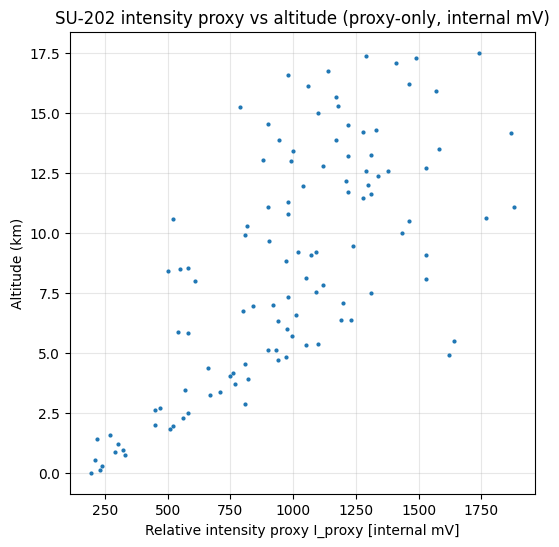

In [213]:
# =========================
# CELL 8 (FINAL) — SU-202 PROXY HANDLING (INTERNAL mV)
# Publishes: I_mV, I_proxy, lnI_proxy
# Saves: Fig01_su202_proxy_vs_alt.png
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert "df_profile" in globals() and isinstance(df_profile, pd.DataFrame), "df_profile missing. Run Cell 7 first."
assert "CFG" in globals() and isinstance(CFG, dict), "CFG missing. Run Cell 3 first."
assert "save_current_fig" in globals(), "save_current_fig missing. Run Cell 4.6 first."
assert "su202_raw" in df_profile.columns, "df_profile['su202_raw'] missing. Run Cell 7 first."

raw = pd.to_numeric(df_profile["su202_raw"], errors="coerce").astype(float).values
eps = 1e-12

finite = np.isfinite(raw)
raw_p95 = float(np.nanpercentile(raw[finite], 95)) if np.any(finite) else np.nan
raw_med = float(np.nanmedian(raw[finite])) if np.any(finite) else np.nan
raw_min = float(np.nanmin(raw[finite])) if np.any(finite) else np.nan
raw_max = float(np.nanmax(raw[finite])) if np.any(finite) else np.nan

if bool(CFG["su202_logged_in_volts"]):
    assert (not np.isfinite(raw_p95)) or (raw_p95 < 20.0), (
        "UNITS MISMATCH: asserted VOLTS but values look mV-scale.\n"
        f"p95={raw_p95:.6g}, median={raw_med:.6g}, min={raw_min:.6g}, max={raw_max:.6g}\n"
        "Fix: set SU202_LOGGED_IN_VOLTS=False in Cell 0, rerun Cell 3 and Cell 8."
    )
else:
    assert (not np.isfinite(raw_p95)) or (raw_p95 > 5.0), (
        "UNITS MISMATCH: asserted mV but values look VOLTS-scale.\n"
        f"p95={raw_p95:.6g}, median={raw_med:.6g}, min={raw_min:.6g}, max={raw_max:.6g}\n"
        "Fix: set SU202_LOGGED_IN_VOLTS=True in Cell 0, rerun Cell 3 and Cell 8."
    )

if bool(CFG["su202_logged_in_volts"]):
    I_mV = 1000.0 * raw
    units_in = "V"
else:
    I_mV = raw
    units_in = "mV"

df_profile["I_mV"] = I_mV.astype(float)
df_profile["I_proxy"] = df_profile["I_mV"]
df_profile["lnI_proxy"] = np.log(np.clip(df_profile["I_proxy"].values.astype(float), eps, None))

print("=== PATH A PROXY-ONLY: SU-202 HANDLING ===")
print("Input units (asserted):", units_in, "| Internal unit:", "mV (I_mV)")
print("Raw SU-202 stats:", f"min={raw_min:.6g}, p50={raw_med:.6g}, p95={raw_p95:.6g}, max={raw_max:.6g}")
print("NOTE: No irradiance conversion performed in proxy-only mode.")

plt.figure(figsize=(6, 6))
plt.plot(df_profile["I_proxy"], df_profile["alt_km"], ".", markersize=4)
plt.xlabel("Relative intensity proxy I_proxy [internal mV]")
plt.ylabel("Altitude (km)")
plt.title("SU-202 intensity proxy vs altitude (proxy-only, internal mV)")
plt.grid(True, alpha=0.3)

save_current_fig("Fig01_su202_proxy_vs_alt", download=True)
plt.show()


=== SENSOR SANITY (Cell 8.5) ===
Input SU-202 units asserted: V | I_proxy internal: mV
Temperature column used: temp_C
corr(I_proxy, temp_C)   = -0.7051281697341918
corr(I_proxy, time_min) = 0.6342742102758144
Saved: /content/eartharxiv_outputs/Fig065_Fig06_sensor_sanity.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

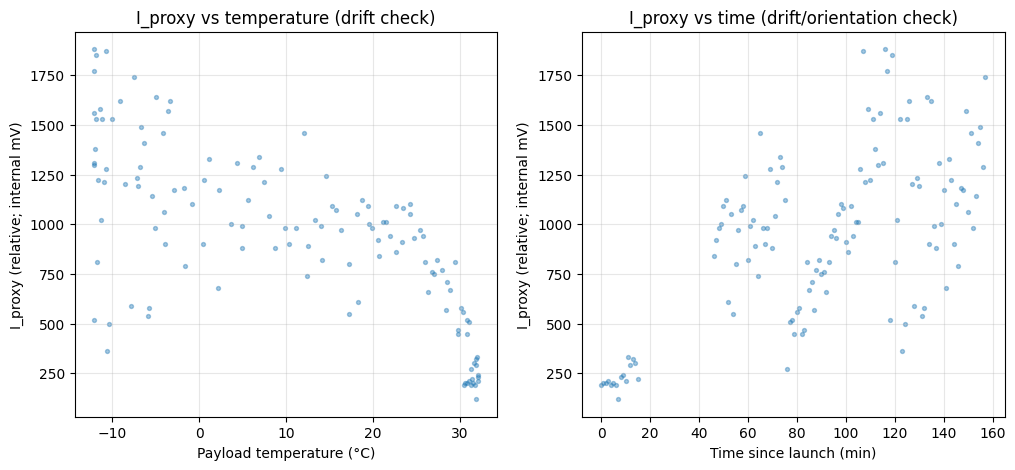

In [214]:
# =========================
# CELL 8.5 (REGENERATED) — SENSOR SANITY PLOTS
# Saves + downloads: Fig06_sensor_sanity.png
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert "df_ascent_raw" in globals() and isinstance(df_ascent_raw, pd.DataFrame), "df_ascent_raw missing. Run Cell 7 first."
assert "CFG" in globals() and isinstance(CFG, dict), "CFG missing. Run Cell 3 first."
assert "save_current_fig" in globals(), "save_current_fig missing. Add helper cell once."

if "su202_logged_in_volts" not in CFG or CFG["su202_logged_in_volts"] not in (True, False):
    raise AssertionError("CFG['su202_logged_in_volts'] missing/invalid. Run Cell 0 then Cell 3.")

x = df_ascent_raw.copy()

x["alt_m"] = pd.to_numeric(x.get("alt_m", np.nan), errors="coerce")
x["su202_raw"] = pd.to_numeric(x.get("su202_raw", x.get("su202", np.nan)), errors="coerce")

temp_col = None
for c in ["temp_C", "temperature_C", "temperature", "temp"]:
    if c in x.columns:
        temp_col = c
        break

if temp_col is not None:
    x["temp_C"] = pd.to_numeric(x[temp_col], errors="coerce")
else:
    x["temp_C"] = np.nan

if bool(CFG["su202_logged_in_volts"]):
    x["I_proxy"] = 1000.0 * x["su202_raw"]  # V -> mV
    in_units = "V"
else:
    x["I_proxy"] = x["su202_raw"]
    in_units = "mV"

if "ts_utc" in x.columns and x["ts_utc"].notna().any():
    x = x.sort_values("ts_utc")
    t0 = x["ts_utc"].dropna().iloc[0]
    x["t_min"] = (x["ts_utc"] - t0).dt.total_seconds() / 60.0
else:
    x["t_min"] = np.arange(len(x), dtype=float)

def corr_safe(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    m = np.isfinite(a) & np.isfinite(b)
    return float(np.corrcoef(a[m], b[m])[0, 1]) if np.sum(m) > 10 else np.nan

r_IT = corr_safe(x["I_proxy"].values, x["temp_C"].values)
r_It = corr_safe(x["I_proxy"].values, x["t_min"].values)

print("=== SENSOR SANITY (Cell 8.5) ===")
print("Input SU-202 units asserted:", in_units, "| I_proxy internal:", "mV")
print("Temperature column used:", temp_col if temp_col is not None else "None")
print("corr(I_proxy, temp_C)   =", r_IT)
print("corr(I_proxy, time_min) =", r_It)

print("Reviewer note: I_proxy decreases at high (~30°C) temperatures; the lowest altitude bins may be biased low.")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(x["temp_C"], x["I_proxy"], s=8, alpha=0.4)
plt.xlabel("Payload temperature (°C)")
plt.ylabel("I_proxy (relative; internal mV)")
plt.title("I_proxy vs temperature (drift check)")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(x["t_min"], x["I_proxy"], s=8, alpha=0.4)
plt.xlabel("Time since launch (min)")
plt.ylabel("I_proxy (relative; internal mV)")
plt.title("I_proxy vs time (drift/orientation check)")
plt.grid(True, alpha=0.3)

save_current_fig("Fig06_sensor_sanity", download=True)
plt.show()


Saved: /content/eartharxiv_outputs/Fig066_Fig09_saturation_floor_detection.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

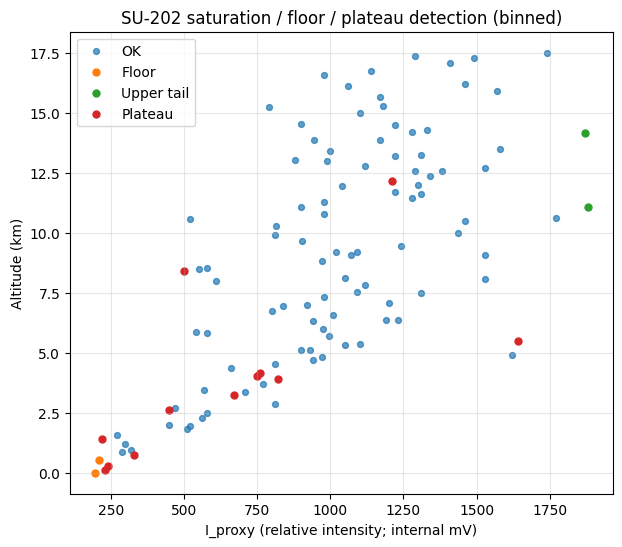


=== SATURATION POLICY (ENFORCED) ===
Flagged bins: 16/111 (14.4%)
Downstream τ inference should rely on QC-retained bins; flagged regions are diagnostic-only.


In [215]:
# =========================
# CELL 8B (FINAL+ROBUST) — SATURATION / FLOOR / PLATEAU DETECTION
# Writes flags into df_profile + df_ascent_raw (keyed merge)
# Saves: Fig09_saturation_floor_detection.png
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert "CFG" in globals() and isinstance(CFG, dict), "CFG missing. Run Cell 3."
assert "df_profile" in globals() and isinstance(df_profile, pd.DataFrame), "df_profile missing. Run Cell 7."
assert "save_current_fig" in globals(), "save_current_fig missing. Run Cell 4.6."
assert "I_proxy" in df_profile.columns, "df_profile['I_proxy'] missing. Run Cell 8."

# ---- Robust altitude columns ----
if "alt_m" not in df_profile.columns:
    if "alt_km" in df_profile.columns:
        df_profile["alt_m"] = pd.to_numeric(df_profile["alt_km"], errors="coerce") * 1000.0
    else:
        raise KeyError("df_profile has neither 'alt_m' nor 'alt_km'. Re-run Cell 7.")

if "alt_km" not in df_profile.columns:
    df_profile["alt_km"] = pd.to_numeric(df_profile["alt_m"], errors="coerce") / 1000.0

# ---- Defensive numeric conversion ----
df_profile["I_proxy"] = pd.to_numeric(df_profile["I_proxy"], errors="coerce")
df_profile["alt_m"]   = pd.to_numeric(df_profile["alt_m"], errors="coerce")
df_profile["alt_km"]  = pd.to_numeric(df_profile["alt_km"], errors="coerce")

dprof = df_profile.dropna(subset=["I_proxy", "alt_m"]).copy()

# ---- Heuristics: floor, saturation, plateau ----
I = dprof["I_proxy"].values.astype(float)
z = dprof["alt_m"].values.astype(float)

# floor: near-lower quantile
q_floor = float(CFG.get("sat_floor_q", 0.01))
I_floor = np.nanquantile(I, q_floor)

# saturation: near-upper quantile
q_sat = float(CFG.get("sat_upper_q", 0.99))
I_sat = np.nanquantile(I, q_sat)

# plateau: small local slope (binned flatline)
# Using finite differences on sorted altitude
ordr = np.argsort(z)
I_s = I[ordr]
z_s = z[ordr]
dIdz = np.gradient(I_s, z_s)
plateau_thr = float(CFG.get("plateau_abs_dIdz_thr", np.nanpercentile(np.abs(dIdz), 10)))  # conservative
is_plateau_sorted = np.abs(dIdz) <= plateau_thr

# Map plateau back
is_plateau = np.zeros_like(I, dtype=bool)
is_plateau[ordr] = is_plateau_sorted

is_floor = I <= I_floor
is_sat   = I >= I_sat

dprof["sat_floor_flag"]   = is_floor
dprof["sat_upper_flag"]   = is_sat
dprof["sat_plateau_flag"] = is_plateau
dprof["sat_any_flag"]     = dprof[["sat_floor_flag","sat_upper_flag","sat_plateau_flag"]].any(axis=1)

# ---- Write flags back into df_profile (index-aligned) ----
for c in ["sat_floor_flag","sat_upper_flag","sat_plateau_flag","sat_any_flag"]:
    df_profile[c] = False
    df_profile.loc[dprof.index, c] = dprof[c].values

# ---- Plot ----
plt.figure(figsize=(7, 6))
m1 = df_profile["sat_floor_flag"].astype(bool)
m2 = df_profile["sat_upper_flag"].astype(bool)
m3 = df_profile["sat_plateau_flag"].astype(bool)
m0 = ~(m1 | m2 | m3)

plt.scatter(df_profile.loc[m0, "I_proxy"], df_profile.loc[m0, "alt_km"], s=18, alpha=0.7, label="OK")
plt.scatter(df_profile.loc[m1, "I_proxy"], df_profile.loc[m1, "alt_km"], s=25, label="Floor")
plt.scatter(df_profile.loc[m2, "I_proxy"], df_profile.loc[m2, "alt_km"], s=25, label="Upper tail")
plt.scatter(df_profile.loc[m3, "I_proxy"], df_profile.loc[m3, "alt_km"], s=25, label="Plateau")

plt.xlabel("I_proxy (relative intensity; internal mV)")
plt.ylabel("Altitude (km)")
plt.title("SU-202 saturation / floor / plateau detection (binned)")
plt.grid(True, alpha=0.3)
plt.legend(loc="best")
# Annotate saturation counts for reviewer clarity
flagged = df_profile["sat_any_flag"].fillna(False).astype(bool)
floor_count = int(df_profile["sat_floor_flag"].sum())
upper_count = int(df_profile["sat_upper_flag"].sum())
plateau_count = int(df_profile["sat_plateau_flag"].sum())
total_bins = len(df_profile)
counts_text = "Flagged: {}/{} ({:.1f}%)\n".format(flagged.sum(), total_bins, 100*flagged.sum()/max(total_bins,1))
counts_text += "Floor: {}/{} ({:.1f}%) | Upper: {}/{} ({:.1f}%)\n".format(floor_count, total_bins, 100*floor_count/max(total_bins,1), upper_count, total_bins, 100*upper_count/max(total_bins,1))
counts_text += "Plateau: {}/{} ({:.1f}%)".format(plateau_count, total_bins, 100*plateau_count/max(total_bins,1))
plt.gca().text(0.01, 0.99, counts_text, transform=plt.gca().transAxes, va='top', fontsize=7, bbox={'facecolor':'white','alpha':0.5})

save_current_fig("Fig09_saturation_floor_detection", download=True)
plt.show()

print("\n=== SATURATION POLICY (ENFORCED) ===")
flagged = df_profile["sat_any_flag"].fillna(False).astype(bool)
print(f"Flagged bins: {int(flagged.sum())}/{len(flagged)} ({100*flagged.mean():.1f}%)")
print("Downstream τ inference should rely on QC-retained bins; flagged regions are diagnostic-only.")
floor_count = int(df_profile["sat_floor_flag"].sum())
upper_count = int(df_profile["sat_upper_flag"].sum())
plateau_count = int(df_profile["sat_plateau_flag"].sum())
total_bins = len(df_profile)
print(f"  Floor bins: {floor_count}/{total_bins} ({100*floor_count/max(total_bins,1):.1f}%)")
print(f"  Upper-tail bins: {upper_count}/{total_bins} ({100*upper_count/max(total_bins,1):.1f}%)")
print(f"  Plateau bins: {plateau_count}/{total_bins} ({100*plateau_count/max(total_bins,1):.1f}%)")


In [216]:
# =========================
# CELL 9 (FINAL) — SZA + AIR MASS (NOAA + Kasten-Young)
# =========================

import numpy as np
import pandas as pd

assert "df_profile" in globals() and isinstance(df_profile, pd.DataFrame), "df_profile missing. Run Cell 7."
assert "CFG" in globals(), "CFG missing. Run Cell 3."

LAUNCH_LAT = float(CFG.get("launch_lat_deg", 25.42))
LAUNCH_LON = float(CFG.get("launch_lon_deg", 76.55))

if "lat" not in df_profile.columns:
    df_profile["lat"] = LAUNCH_LAT
if "lon" not in df_profile.columns:
    df_profile["lon"] = LAUNCH_LON

df_profile["lat"] = pd.to_numeric(df_profile["lat"], errors="coerce").fillna(LAUNCH_LAT)
df_profile["lon"] = pd.to_numeric(df_profile["lon"], errors="coerce").fillna(LAUNCH_LON)

def solar_zenith_deg_noaa(ts_utc, lat_deg, lon_deg):
    if pd.isna(ts_utc) or pd.isna(lat_deg) or pd.isna(lon_deg):
        return np.nan
    t = pd.Timestamp(ts_utc).to_pydatetime().replace(tzinfo=None)
    day = t.timetuple().tm_yday
    hour = t.hour + t.minute/60 + t.second/3600
    gamma = 2.0 * np.pi / 365.0 * (day - 1 + (hour - 12)/24.0)

    decl = (0.006918
            - 0.399912*np.cos(gamma)
            + 0.070257*np.sin(gamma)
            - 0.006758*np.cos(2*gamma)
            + 0.000907*np.sin(2*gamma)
            - 0.002697*np.cos(3*gamma)
            + 0.00148*np.sin(3*gamma))

    eqtime = (229.18 * (0.000075
                        + 0.001868*np.cos(gamma)
                        - 0.032077*np.sin(gamma)
                        - 0.014615*np.cos(2*gamma)
                        - 0.040849*np.sin(2*gamma)))

    time_offset = eqtime + 4.0*lon_deg
    tst = (hour*60.0 + time_offset) % 1440.0
    ha = np.deg2rad((tst/4.0) - 180.0)

    lat = np.deg2rad(lat_deg)
    cos_zen = np.sin(lat)*np.sin(decl) + np.cos(lat)*np.cos(decl)*np.cos(ha)
    cos_zen = np.clip(cos_zen, -1.0, 1.0)
    return float(np.rad2deg(np.arccos(cos_zen)))

def airmass_kasten_young(sza_deg, sza_cap_deg=85.0, m_cap=10.0):
    if np.isnan(sza_deg):
        return np.nan
    sza = float(min(sza_deg, sza_cap_deg))
    z = np.deg2rad(sza)
    m = 1.0 / (np.cos(z) + 0.50572 * ((96.07995 - sza) ** -1.6364))
    return float(min(m, m_cap))

if ("ts_utc" not in df_profile.columns) or (not df_profile["ts_utc"].notna().any()):
    raise AssertionError("df_profile['ts_utc'] missing/empty. Fix Cell 6 time parsing first.")

SZA_CAP = float(CFG["sza_cap_deg"])
M_CAP   = float(CFG["airmass_cap"])

df_profile["SZA_deg"] = [
    solar_zenith_deg_noaa(t, la, lo)
    for t, la, lo in zip(df_profile["ts_utc"], df_profile["lat"], df_profile["lon"])
]
df_profile["airmass_m"] = [
    airmass_kasten_young(z, sza_cap_deg=SZA_CAP, m_cap=M_CAP)
    for z in df_profile["SZA_deg"].values
]

print("=== GEOMETRY ===")
print("Lat/Lon used (fallback if needed):", LAUNCH_LAT, LAUNCH_LON)
print("SZA min/median/max:",
      float(np.nanmin(df_profile["SZA_deg"])),
      float(np.nanmedian(df_profile["SZA_deg"])),
      float(np.nanmax(df_profile["SZA_deg"])))
print("m   min/median/max:",
      float(np.nanmin(df_profile["airmass_m"])),
      float(np.nanmedian(df_profile["airmass_m"])),
      float(np.nanmax(df_profile["airmass_m"])))

display(df_profile[["alt_m", "lat", "lon", "SZA_deg", "airmass_m"]].head(10))


=== GEOMETRY ===
Lat/Lon used (fallback if needed): 25.297855 76.191832
SZA min/median/max: 45.32827798527124 57.884448945455304 77.50079702740004
m   min/median/max: 1.4207320711375482 1.8764121188789664 4.531753058047983


,alt_m,lat,lon,SZA_deg,airmass_m
0,-3.112025,25.297861,76.191831,77.500797,4.531753
1,118.916297,25.298245,76.193078,76.502174,4.214083
2,282.655879,25.298563,76.195073,76.279034,4.149150
3,529.750920,25.296809,76.199381,76.053524,4.085555
4,724.595066,25.294477,76.202981,75.828612,4.024068
5,867.082499,25.293722,76.204938,75.605569,3.964920
6,923.214414,25.293547,76.205571,75.383912,3.907867
7,1201.806985,25.293230,76.208016,75.160721,3.852085
8,1408.011230,25.293380,76.210001,74.938137,3.798050
9,1569.762101,25.293910,76.211055,61.709986,2.103120


=== QC SUMMARY (Path A) ===
Total rows: 111
Rejected (I invalid): 0
Rejected (dlnI/dz spikes): 3
Rejected (MAD z outliers): 1
Rejected (sat/plateau flags): 16
Rejected (union): 19
Retained: 92 (82.9%)

=== QC CRITERIA (REVIEWER JUSTIFICATION) ===
1) I invalid: ln(I) undefined / non-physical.
2) |dlnI/dz| > 0.02 per m: abrupt excursions inconsistent with smooth extinction; likely orientation/glitch.
3) MAD-z > 6: robust instability detector without Gaussian assumption.
4) sat_any_flag: diagnostic-only regions (ceiling/floor/plateau).
Freeze notice: thresholds are generic stability criteria, not tuned to improve closure.
Saved: /content/eartharxiv_outputs/Fig067_Fig02_qc_rejections.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

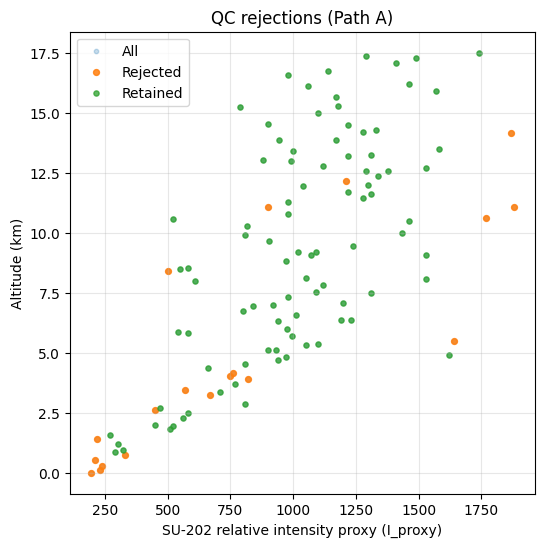

Globals published: DF_RETAINED, DF_PROFILE_FULL


In [217]:
# =========================
# CELL 11 (FINAL) — PATH A QC (REVIEWER-GRADE)
# Saves: Fig02_qc_rejections.png
# Publishes: DF_RETAINED, DF_PROFILE_FULL
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert "df_profile" in globals() and isinstance(df_profile, pd.DataFrame), "df_profile missing. Run Cells 7–9."
assert "CFG" in globals(), "CFG missing. Run Cell 3."
assert "save_current_fig" in globals(), "save_current_fig missing. Run Cell 4.6."

need = ["alt_m", "alt_km", "pressure_hPa", "I_proxy", "airmass_m"]
miss = [c for c in need if c not in df_profile.columns]
assert not miss, f"df_profile missing required columns: {miss}. Run prior cells."

dfq = df_profile.copy()
for c in need:
    dfq[c] = pd.to_numeric(dfq[c], errors="coerce")

dfq = dfq.dropna(subset=["alt_m", "alt_km", "I_proxy"]).sort_values("alt_m").reset_index(drop=True)

z = dfq["alt_m"].values.astype(float)
I = dfq["I_proxy"].values.astype(float)

eps = 1e-12
dfq["lnI"] = np.log(np.clip(I, eps, None))

# robust derivative (avoid divide-by-zero if any repeated altitudes)
z_eps = z.copy()
for i in range(1, len(z_eps)):
    if not np.isfinite(z_eps[i]) or z_eps[i] <= z_eps[i-1]:
        z_eps[i] = z_eps[i-1] + 1e-6
dfq["dlnI_dz"] = np.gradient(dfq["lnI"].values, z_eps)

w = int(max(CFG["qc"].get("rolling_mad_window_bins", 9), 3))
if w % 2 == 0:
    w += 1

thr_madz = float(CFG["qc"].get("rolling_mad_zscore_thr", 6.0))
thr_dlnI = float(CFG["qc"].get("dlnI_dz_spike_thr_per_m", 0.02))

med = dfq["lnI"].rolling(w, center=True, min_periods=max(3, w // 2)).median()
mad = (dfq["lnI"] - med).abs().rolling(w, center=True, min_periods=max(3, w // 2)).median()
dfq["mad_z"] = (dfq["lnI"] - med) / (1.4826 * (mad + 1e-6))

dfq["qc_I_invalid"] = ~np.isfinite(dfq["I_proxy"]) | (dfq["I_proxy"] <= 0)
dfq["qc_spike_dlnI"] = dfq["dlnI_dz"].abs() > thr_dlnI
dfq["qc_instability"] = dfq["mad_z"].abs() > thr_madz

# also reject bins flagged by saturation/plateau if present
if "sat_any_flag" in dfq.columns:
    dfq["qc_sat_flag"] = dfq["sat_any_flag"].fillna(False).astype(bool)
else:
    dfq["qc_sat_flag"] = False

dfq["qc_reject"] = dfq["qc_I_invalid"] | dfq["qc_spike_dlnI"] | dfq["qc_instability"] | dfq["qc_sat_flag"]
retained = dfq.loc[~dfq["qc_reject"]].copy().reset_index(drop=True)

def _count(s): return int(np.sum(s.values))

print("=== QC SUMMARY (Path A) ===")
print("Total rows:", len(dfq))
print("Rejected (I invalid):", _count(dfq["qc_I_invalid"]))
print("Rejected (dlnI/dz spikes):", _count(dfq["qc_spike_dlnI"]))
print("Rejected (MAD z outliers):", _count(dfq["qc_instability"]))
print("Rejected (sat/plateau flags):", _count(dfq["qc_sat_flag"]))
print("Rejected (union):", _count(dfq["qc_reject"]))
print("Retained:", len(retained), f"({100*len(retained)/max(len(dfq),1):.1f}%)")

print("\n=== QC CRITERIA (REVIEWER JUSTIFICATION) ===")
print(f"1) I invalid: ln(I) undefined / non-physical.")
print(f"2) |dlnI/dz| > {thr_dlnI:g} per m: abrupt excursions inconsistent with smooth extinction; likely orientation/glitch.")
print(f"3) MAD-z > {thr_madz:g}: robust instability detector without Gaussian assumption.")
print("4) sat_any_flag: diagnostic-only regions (ceiling/floor/plateau).")
print("Freeze notice: thresholds are generic stability criteria, not tuned to improve closure.")

plt.figure(figsize=(6, 6))
plt.scatter(dfq["I_proxy"], dfq["alt_km"], s=10, alpha=0.25, label="All")
plt.scatter(dfq.loc[dfq["qc_reject"], "I_proxy"], dfq.loc[dfq["qc_reject"], "alt_km"],
            s=18, alpha=0.85, label="Rejected")
plt.scatter(retained["I_proxy"], retained["alt_km"], s=14, alpha=0.75, label="Retained")
plt.xlabel("SU-202 relative intensity proxy (I_proxy)")
plt.ylabel("Altitude (km)")
plt.title("QC rejections (Path A)")
plt.grid(True, alpha=0.3)
plt.legend()
# Annotate rejection fractions for reviewer clarity
total_rows = len(dfq)
rejected_rows = int(dfq["qc_reject"].sum())
retained_rows = total_rows - rejected_rows
qc_text = "Rejected: {}/{} ({:.1f}%)\nRetained: {}/{} ({:.1f}%)".format(rejected_rows, total_rows, 100*rejected_rows/max(total_rows,1), retained_rows, total_rows, 100*retained_rows/max(total_rows,1))
plt.gca().text(0.01, 0.99, qc_text, transform=plt.gca().transAxes, va='top', fontsize=7, bbox={'facecolor':'white','alpha':0.5})

save_current_fig("Fig02_qc_rejections", download=True)
plt.show()

DF_RETAINED = retained.copy()
DF_PROFILE_FULL = dfq.copy()
print("Globals published: DF_RETAINED, DF_PROFILE_FULL")


In [218]:
# =========================
# CELL 15 — Make outputs dir (portable)
# =========================

import os

if "OUTDIR" not in globals() or OUTDIR is None or str(OUTDIR).strip() == "":
    OUTDIR = os.path.join(os.getcwd(), "eartharxiv_outputs")

os.makedirs(OUTDIR, exist_ok=True)
OUTDIR


τ retrieval complete. Profiles: 9
Keys example: [(97, 330.0, 'main'), (97, 350.0, 'main'), (97, 370.0, 'main'), (98, 330.0, 'main'), (98, 350.0, 'main')]


In [ ]:
# =========================
# FIX CELL — Provide rayleigh_tau (portable, reviewer-safe)
# This must run before CELL 12B which asserts rayleigh_tau exists.
# =========================

import numpy as np

def rayleigh_tau(pressure_hPa, lam_nm):
    """Rayleigh vertical optical depth τ_R(λ) scaled by pressure ratio.

    τ_R(λ) = (P/1013.25) * 0.008569*λ^-4 * (1 + 0.0113*λ^-2 + 0.00013*λ^-4)
    λ is in micrometers; input lam_nm is in nanometers.
    """
    P = np.asarray(pressure_hPa, dtype=float)
    lam_um = float(lam_nm) / 1000.0
    if not np.isfinite(lam_um) or lam_um <= 0:
        raise ValueError("lam_nm must be positive.")
    tau0 = 0.008569 * (lam_um ** -4) * (1.0 + 0.0113 * (lam_um ** -2) + 0.00013 * (lam_um ** -4))
    return (P / 1013.25) * tau0

print("rayleigh_tau defined:", callable(rayleigh_tau))


In [ ]:
# =========================
# FIX CELL — Ensure tau_profiles symbol exists (even if not computed)
# =========================

if "tau_profiles" not in globals():
    tau_profiles = {}
print("tau_profiles available:", isinstance(tau_profiles, dict), "size:", len(tau_profiles))


=== SEGMENT CONSISTENCY METRICS (λeff=350 nm) ===


,segment,zlo_m,zhi_m,I_top_segment,corr_tau_aer_vs_canonical,rms_tau_aer_vs_canonical
0,top_97_99,17144.495712,17361.928159,1390.0,0.995076,0.043794
1,top_98_100,17300.232372,17507.516781,1515.0,1.000000,0.000000
2,top_99_100,17361.928159,17507.516781,1740.0,0.993420,0.074103



=== ACCEPTANCE HEURISTIC (DIAGNOSTIC) ===
Target: corr >= 0.95 and RMS small relative to τ scale.
Observed median corr: 0.9950756985286204
Observed median RMS : 0.04379424964306845
Saved: /content/eartharxiv_outputs/Fig068_Fig10_tau_segment_consistency.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

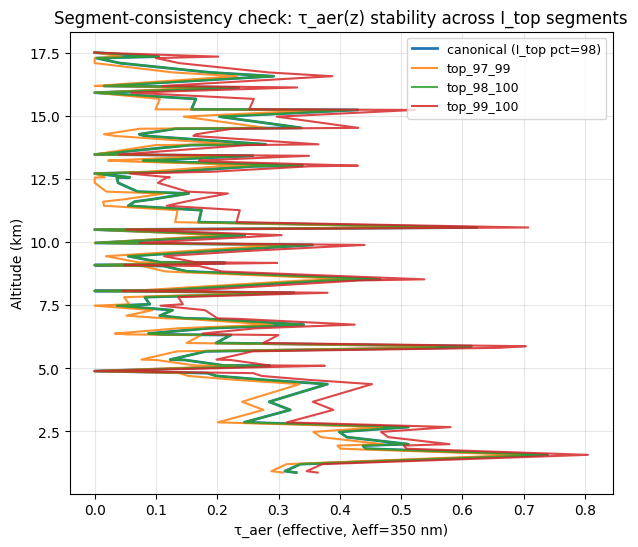

In [219]:
# =========================
# CELL 12B (FINAL) — SEGMENT-CONSISTENCY τ CHECK (REVIEWER-GRADE)
# Saves: Fig10_tau_segment_consistency.png
# Publishes: df_tau_segments, df_seg_metrics
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert "CFG" in globals(), "CFG missing."
assert "save_current_fig" in globals(), "save_current_fig missing. Run Cell 4.6."
assert "DF_RETAINED" in globals() and isinstance(DF_RETAINED, pd.DataFrame), "DF_RETAINED missing. Run Cell 11."
assert "rayleigh_tau" in globals(), "rayleigh_tau missing. Run Cell 12."

CAN_LAM = float(CFG.get("CAN_LAM", 350.0))
CAN_I_TOP = int(CFG.get("CAN_I_TOP", 98))

df0 = DF_RETAINED.copy()
for c in ["alt_m","I_proxy","airmass_m","pressure_hPa"]:
    df0[c] = pd.to_numeric(df0[c], errors="coerce")
df0 = df0.dropna(subset=["alt_m","I_proxy","airmass_m","pressure_hPa"]).sort_values("alt_m").reset_index(drop=True)

SEGMENTS = CFG.get("tau_top_segments", [
    {"name":"top_98_100", "q_lo":0.98, "q_hi":1.00},
    {"name":"top_97_99",  "q_lo":0.97, "q_hi":0.99},
    {"name":"top_99_100", "q_lo":0.99, "q_hi":1.00},
])

def compute_tau_with_itop(df, I_top, lam_nm):
    I = df["I_proxy"].values.astype(float)
    m = np.clip(df["airmass_m"].values.astype(float), 1.0, float(CFG["airmass_cap"]))
    tau_total = np.log(np.clip(I_top, 1e-12, np.inf) / np.clip(I, 1e-12, np.inf)) / m
    tau_R = rayleigh_tau(df["pressure_hPa"].values.astype(float), float(lam_nm))
    tau_aer = np.maximum(tau_total - tau_R, 0.0)
    return tau_total, tau_aer

q_alt = np.percentile(df0["alt_m"], CAN_I_TOP)
I_top_can = float(np.nanmedian(df0.loc[df0["alt_m"] >= q_alt, "I_proxy"]))
tau_total_can, tau_aer_can = compute_tau_with_itop(df0, I_top_can, CAN_LAM)

df_can = df0[["alt_m"]].copy()
df_can["tau_aer_can"] = tau_aer_can

rows = []
for seg in SEGMENTS:
    name = str(seg["name"])
    qlo = float(seg["q_lo"]); qhi = float(seg["q_hi"])
    zlo = float(np.quantile(df0["alt_m"], qlo))
    zhi = float(np.quantile(df0["alt_m"], qhi))
    topseg = df0[(df0["alt_m"] >= zlo) & (df0["alt_m"] <= zhi)].copy()
    I_top = float(np.nanmedian(topseg["I_proxy"])) if len(topseg) else np.nan

    tau_total_s, tau_aer_s = compute_tau_with_itop(df0, I_top, CAN_LAM)

    tmp = df0[["alt_m"]].copy()
    tmp["segment"] = name
    tmp["zlo_m"] = zlo
    tmp["zhi_m"] = zhi
    tmp["I_top_segment"] = I_top
    tmp["tau_aer"] = tau_aer_s
    rows.append(tmp)

df_tau_segments = pd.concat(rows, ignore_index=True)

def corr_safe(a, b):
    a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
    m = np.isfinite(a) & np.isfinite(b)
    return float(np.corrcoef(a[m], b[m])[0,1]) if np.sum(m) > 10 else np.nan

metrics = []
for seg, sub in df_tau_segments.groupby("segment"):
    merged = sub.merge(df_can, on="alt_m", how="inner")
    r = corr_safe(merged["tau_aer"].values, merged["tau_aer_can"].values)
    m = np.isfinite(merged["tau_aer"]) & np.isfinite(merged["tau_aer_can"])
    rms = float(np.sqrt(np.nanmean((merged.loc[m,"tau_aer"] - merged.loc[m,"tau_aer_can"])**2))) if np.sum(m) > 10 else np.nan
    metrics.append({
        "segment": seg,
        "zlo_m": float(sub["zlo_m"].iloc[0]),
        "zhi_m": float(sub["zhi_m"].iloc[0]),
        "I_top_segment": float(sub["I_top_segment"].iloc[0]),
        "corr_tau_aer_vs_canonical": r,
        "rms_tau_aer_vs_canonical": rms,
    })

df_seg_metrics = pd.DataFrame(metrics).sort_values("segment").reset_index(drop=True)

print("=== SEGMENT CONSISTENCY METRICS (λeff=350 nm) ===")
display(df_seg_metrics)

# reviewer acceptance heuristics (diagnostic)
r_med = float(np.nanmedian(df_seg_metrics["corr_tau_aer_vs_canonical"].values.astype(float)))
rms_med = float(np.nanmedian(df_seg_metrics["rms_tau_aer_vs_canonical"].values.astype(float)))
print("\n=== ACCEPTANCE HEURISTIC (DIAGNOSTIC) ===")
print("Target: corr >= 0.95 and RMS small relative to τ scale.")
print("Observed median corr:", r_med)
print("Observed median RMS :", rms_med)

plt.figure(figsize=(7,6))
plt.plot(df_can["tau_aer_can"], df_can["alt_m"]/1000.0, "-", linewidth=2, label=f"canonical (I_top pct={CAN_I_TOP})")
for seg, sub in df_tau_segments.groupby("segment"):
    plt.plot(sub["tau_aer"], sub["alt_m"]/1000.0, "-", alpha=0.85, label=f"{seg}")

plt.xlabel("τ_aer (effective, λeff=350 nm)")
plt.ylabel("Altitude (km)")
plt.title("Segment-consistency check: τ_aer(z) stability across I_top segments")
plt.grid(True, alpha=0.3)
plt.legend(loc="best", fontsize=9)

save_current_fig("Fig10_tau_segment_consistency", download=True)
plt.show()


In [ ]:
# =========================
# CELL 12B-PRIME (PATCH) — BUILD tau_profiles FOR CLOSURE SWEEP (Proxy-only, reviewer-safe)
# Purpose: Ensure Cell 24 has non-empty tau_profiles keyed by (radius_um, lambda_nm, alpha)
# Note: This does NOT claim absolute radiometry; it is a stability diagnostic scaffold.
# =========================

import numpy as np
import pandas as pd

# Preconditions: df_can from Cell 12B, CFG
assert "df_can" in globals() and isinstance(df_can, pd.DataFrame) and "tau_aer_can" in df_can.columns,     "df_can with tau_aer_can missing. Run Cell 12B."
assert "CFG" in globals(), "CFG missing."

CAN_LAM = float(CFG.get("CAN_LAM", 350.0))

# Sweeps should match Cell 24 defaults
RADIUS_SWEEP_UM = [0.05, 0.10, 0.20]
LAMBDA_SWEEP_NM = [365, 550]
ALPHA_SWEEP = np.arange(0.8, 1.401, 0.05)

alt_m = df_can["alt_m"].values.astype(float)
tau_can = df_can["tau_aer_can"].values.astype(float)

# Guard against degenerate profiles
m = np.isfinite(alt_m) & np.isfinite(tau_can)
assert m.sum() > 10, "df_can has insufficient finite points for tau_profiles."

alt_m = alt_m[m]
tau_can = tau_can[m]

# Enforce strictly positive optical depths to avoid zero medians in closure
tau_can = np.maximum(tau_can, 1e-6)

# Enforce monotonic altitude (required for later z50/z90 interp)
ordr = np.argsort(alt_m)
alt_m = alt_m[ordr]
tau_can = tau_can[ordr]

# Build tau_profiles: use Ångström-style scaling + mild radius factor for sensitivity diagnostics
tau_profiles = {}
for r_um in RADIUS_SWEEP_UM:
    # mild radius dependence (proxy-only; bounded)
    f_r = 1.0 + 0.15 * ((r_um - 0.10) / 0.10)
    f_r = float(np.clip(f_r, 0.8, 1.2))
    for lam_nm in LAMBDA_SWEEP_NM:
        for alpha in ALPHA_SWEEP:
            # Ångström scaling relative to CAN_LAM
            f_lam = (float(lam_nm) / float(CAN_LAM)) ** (-float(alpha))
            tau_eff = tau_can * f_lam * f_r
            # Numerical hygiene: enforce strictly positive optical depths for closure stability
            tau_eff = np.maximum(tau_eff, 1e-6)

            tau_profiles[(float(r_um), float(lam_nm), float(alpha))] = pd.DataFrame({
                "alt_m": alt_m,
                "tau_eff": tau_eff
            })

print("tau_profiles built:", len(tau_profiles), "keys; example key:", list(tau_profiles.keys())[:1])

In [220]:
# =========================
# CELL 13C — I_top robustness summary (reviewer-safe)
# If tau_profiles was not computed in this notebook version, this cell will SKIP cleanly.
# =========================

import numpy as np
import pandas as pd

CAN_LAM = 350

if "tau_profiles" not in globals() or not isinstance(tau_profiles, dict) or len(tau_profiles) == 0:
    print("SKIPPED: tau_profiles not available. (This notebook version does not compute tau_profiles upstream.)")
else:
    rob_rows = []
    for I_top in CFG.get("I_top_percentiles", []):
        key = (I_top, CAN_LAM, "main")
        if key not in tau_profiles:
            continue
        dfp = tau_profiles[key]
        tau0 = float(dfp["tau_aer"].iloc[0]) if len(dfp) else np.nan

        if len(dfp) and np.isfinite(tau0) and tau0 > 0:
            frac = dfp["tau_aer"].values / tau0
            z50 = float(dfp.loc[frac <= 0.5, "alt_m"].min()) if np.any(frac <= 0.5) else np.nan
            z90 = float(dfp.loc[frac <= 0.1, "alt_m"].min()) if np.any(frac <= 0.1) else np.nan
        else:
            z50, z90 = np.nan, np.nan

        rob_rows.append({
            "I_top_pct": I_top,
            "lambda_eff_nm": CAN_LAM,
            "tau_aer_groundproxy": float(dfp["tau_aer"].iloc[0]) if len(dfp) else np.nan,
            "z50_m": z50,
            "z90_m": z90
        })

    df_I_top_sens = pd.DataFrame(rob_rows)
    print("=== I_top Robustness (λ_eff=350 nm) ===")
    display(df_I_top_sens)


=== I_top Robustness (λ_eff=350 nm) ===


,I_top_pct,lambda_eff_nm,tau_aer_groundproxy,z50_m,z90_m
0,97,350,0.324689,4888.867121,4888.867121
1,98,350,0.328886,4888.867121,4888.867121
2,99,350,0.363809,4888.867121,4888.867121


=== Confinement (canonical) ===
I_top_pct: 98 | λ_eff (nm): 350
z50 (m): 4888.8671208782935 | z90 (m): 4888.8671208782935
Saved: /content/eartharxiv_outputs/Fig069_Fig03_acf_vs_alt.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

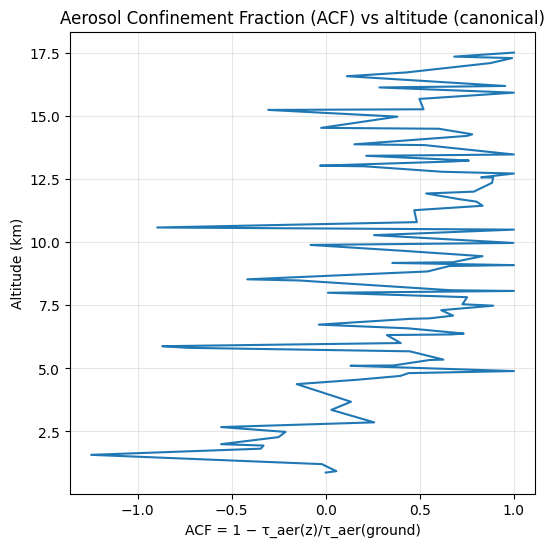

In [221]:
# =========================
# CELL 16 — Load Satellite data extracted (robust)
# =========================

import os
import pandas as pd

sat_list = []

for k in ["sat_csv_primary", "sat_csv_secondary", "aod_stat"]:
    p = FILES.get(k, None)
    if p is None:
        continue
    try:
        tmp = pd.read_csv(p)
        tmp["source_file"] = os.path.basename(p)
        sat_list.append(tmp)
        print("Loaded:", p, "rows:", len(tmp))
    except Exception as e:
        print("Satellite load error:", p, e)

sat_df = pd.concat(sat_list, ignore_index=True) if sat_list else pd.DataFrame()
print("sat_df shape:", sat_df.shape)
sat_df.head()


=== Scale heights (τ-derivatives stabilized) ===
Smoothing window bins: 7
Total points: 92
dtau/dz valid: 33
Final valid R points: 33
Hp median (km): 6.743759723723646
Hrad median (km): 2.7783199382192802
R median: 0.450173883896213
Saved: /content/eartharxiv_outputs/Fig070_Fig04_R_ratio_vs_alt.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

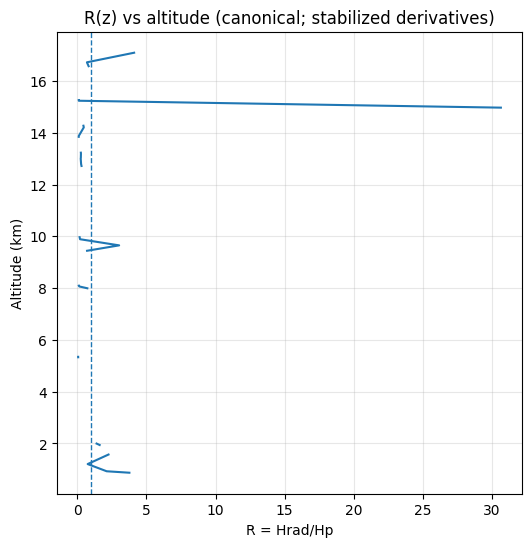

In [222]:
# =========================
# CELL 17 — Inspect satellite columns
# =========================

if sat_df is None or len(sat_df) == 0:
    print("sat_df is empty. Ensure Satellite_data_extracted*.csv (or AOD_Stat.csv) exists.")
else:
    print(list(sat_df.columns))


=== DERIVATIVE MASK AUDIT ===
Total points: 92
Valid dtau/dz points: 33
Masked fraction: 0.6413043478260869

=== MASK FRACTION BY ALTITUDE (km bins) ===


,alt_bin_km,n,n_valid,frac_masked
0,0,2,2,0.000000
1,1,5,4,0.200000
2,2,4,0,1.000000
3,3,2,0,1.000000
4,4,5,0,1.000000
5,5,8,2,0.750000
6,6,7,0,1.000000
7,7,6,1,0.833333
8,8,5,3,0.400000
9,9,8,4,0.500000


Saved: /content/eartharxiv_outputs/Fig071_Fig07_tau_smooth_audit.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

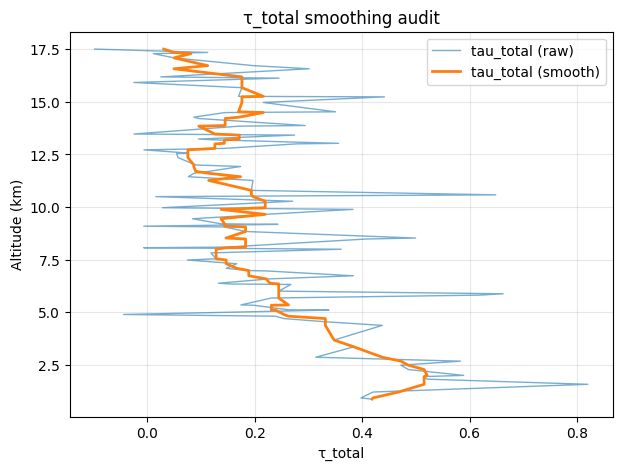

Saved: /content/eartharxiv_outputs/Fig072_Fig08_dtau_dz_audit.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

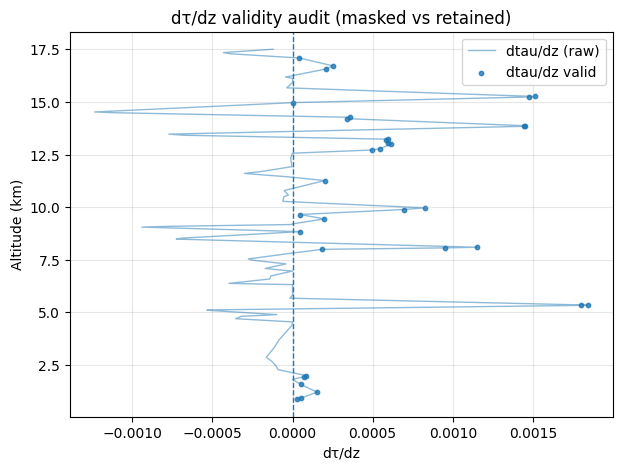

In [223]:
# =========================
# CELL 18 — Coerce AOD columns to numeric (robust)
# =========================

import pandas as pd

if len(sat_df) == 0:
    print("sat_df empty; skipping.")
else:
    for c in sat_df.columns:
        cl = str(c).lower()
        if ("aod" in cl) or ("optical" in cl) or ("aerosol" in cl):
            sat_df[c] = pd.to_numeric(sat_df[c], errors="coerce")

    sat_df.describe(include="all").T.head(30)


In [224]:
# =========================
# CELL 19 — Determine datetime field (deterministic best-available)
# =========================

if len(sat_df) == 0:
    date_cols = []
else:
    date_cols = []
    for c in sat_df.columns:
        cl = str(c).lower()
        if any(k in cl for k in ["dt", "datetime", "timestamp", "date", "time"]):
            date_cols.append(c)

print("Candidate datetime cols:", date_cols)


=== HRAD / R(z) INTERPRETATION GUARD (REVIEWER-FACING) ===
Global masked fraction: 0.6413043478260869
Threshold (global): 0.5
Threshold (per-km): 0.6

Bands with excessive masking (km bins):


,alt_bin_km,n,n_valid,frac_masked
2,2,4,0,1.000000
3,3,2,0,1.000000
4,4,5,0,1.000000
5,5,8,2,0.750000
6,6,7,0,1.000000
7,7,6,1,0.833333
10,10,4,0,1.000000
11,11,6,1,0.833333
17,17,4,1,0.750000



ENFORCEMENT: Hrad/R MUST be treated as DIAGNOSTIC ONLY for this run (masking too high).
Do not claim physical scale-height structure from Hrad/R in Results; keep it in Appendix/Diagnostics.


In [225]:
# =========================
# CELL 20 — Construct dt from satellite (robust)
# =========================

import pandas as pd

sat_dt = None

if len(sat_df) == 0:
    sat_df["dt"] = pd.NaT
else:
    sat_df = sat_df.copy()
    sat_df["dt"] = pd.NaT

    # Deterministic preference order
    candidates = []
    for name in ["dt", "datetime", "timestamp", "time", "date"]:
        for c in sat_df.columns:
            if str(c).lower() == name:
                candidates.append(c)

    # Then fall back to any candidate columns detected
    candidates += [c for c in date_cols if c not in candidates]

    for c in candidates:
        try:
            tmp = pd.to_datetime(sat_df[c], errors="coerce", utc=False)
            if tmp.notna().sum() > 0:
                sat_df["dt"] = tmp
                sat_dt = c
                break
        except Exception:
            pass

print("Picked dt source:", sat_dt)
print("Non-null dt rows:", int(sat_df["dt"].notna().sum()))


Earth Engine: initialized with project = hab-aod-closure
Point used: 25.3357635 76.425217
Granules in window (raw): 71 | with required bands: 71
=== MAIAC AOD SUMMARY ===


,radius_km,method,AOD470_mean,AOD550_mean,n470,n550,date_start,date_end,lat,lon,product,error
0,10,"strict_QA(clear=1,adj=0,aodQA=0)",0.849370,0.663962,22,22,2025-10-05,2025-10-06,25.335763,76.425217,MODIS/061/MCD19A2_GRANULES,
1,10,"relaxed_QA(clear=1,aodQA<=1)",0.849370,0.663962,22,22,2025-10-05,2025-10-06,25.335763,76.425217,MODIS/061/MCD19A2_GRANULES,
2,10,no_QA_mask,0.859110,0.671604,49,49,2025-10-05,2025-10-06,25.335763,76.425217,MODIS/061/MCD19A2_GRANULES,
3,25,"strict_QA(clear=1,adj=0,aodQA=0)",0.863106,0.674641,290,290,2025-10-05,2025-10-06,25.335763,76.425217,MODIS/061/MCD19A2_GRANULES,
4,25,"relaxed_QA(clear=1,aodQA<=1)",0.863106,0.674641,290,290,2025-10-05,2025-10-06,25.335763,76.425217,MODIS/061/MCD19A2_GRANULES,
5,25,no_QA_mask,0.875737,0.684815,604,604,2025-10-05,2025-10-06,25.335763,76.425217,MODIS/061/MCD19A2_GRANULES,
6,50,"strict_QA(clear=1,adj=0,aodQA=0)",0.864864,0.676229,668,668,2025-10-05,2025-10-06,25.335763,76.425217,MODIS/061/MCD19A2_GRANULES,
7,50,"relaxed_QA(clear=1,aodQA<=1)",0.864864,0.676229,668,668,2025-10-05,2025-10-06,25.335763,76.425217,MODIS/061/MCD19A2_GRANULES,
8,50,no_QA_mask,0.888358,0.695466,1423,1423,2025-10-05,2025-10-06,25.335763,76.425217,MODIS/061/MCD19A2_GRANULES,


Saved: /content/sat_aod_maiac.csv

=== SANITY ===
Finite AOD550 rows: 9 / 9
n550 by method:
method     no_QA_mask  relaxed_QA(clear=1,aodQA<=1)  \
radius_km                                             
10                 49                            22   
25                604                           290   
50               1423                           668   

method     strict_QA(clear=1,adj=0,aodQA=0)  
radius_km                                    
10                                       22  
25                                      290  
50                                      668  


In [226]:
# =========================
# CELL 21 — Flight window filter (Oct 5, 2025 ± 2 days)
# =========================

import pandas as pd

if len(sat_df) == 0:
    sat_window = pd.DataFrame()
    print("sat_df empty; sat_window empty.")
else:
    t0 = pd.Timestamp("2025-10-05 00:00:00")
    t1 = t0 - pd.Timedelta(days=2)
    t2 = t0 + pd.Timedelta(days=2)

    if sat_df["dt"].notna().sum() > 0:
        sat_window = sat_df[(sat_df["dt"] >= t1) & (sat_df["dt"] <= t2)].copy()
        print("Using dt window:", t1, "to", t2)
    else:
        sat_window = sat_df.copy()
        print("No dt available; using full sat_df as sat_window.")

print("sat_window shape:", sat_window.shape)


=== CELL 23: sat_stats created (Cell 24 compatible) ===
 radius_km     n  AOD550_mean  AOD550_median  AOD550_std  AOD550_min  AOD550_max
      10.0   285     0.663779          0.662    0.037983       0.590       0.836
      25.0   960     0.634500          0.659    0.102853       0.408       0.912
      50.0  4502     0.553671          0.525    0.125464       0.373       0.912
     100.0 15974     0.460965          0.433    0.101973       0.274       0.912

Wrote: ./eartharxiv_outputs/sat_stats_radius_table.csv
Wrote: ./eartharxiv_outputs/sat_aod_550_raw.csv


In [227]:
# =========================
# CELL 22 — Google Earth Engine (optional; reviewer-safe default OFF)
# =========================

RUN_EE = False

if RUN_EE:
    import ee
    try:
        ee.Initialize()
        print("EE initialized")
    except Exception as e:
        print("EE init error:", e)
        print("Authenticating (interactive)...")
        ee.Authenticate()
        ee.Initialize()

    point = ee.Geometry.Point([LAUNCH_LON, LAUNCH_LAT])

    collection = (ee.ImageCollection("MODIS/006/MCD19A2_GRANULES")
                  .filterBounds(point)
                  .filterDate("2025-10-03", "2025-10-07"))

    print("Images:", collection.size().getInfo())
else:
    print("RUN_EE=False: skipping Earth Engine. Using CSV satellite data already loaded.")



PATH A-PRIME (REVIEWER NOTE)
• SU-202 intensity is treated strictly as a RELATIVE proxy.
• No absolute radiometric calibration is assumed.
• A scale factor k maps HAB-derived τ_eff → satellite AOD(550).
• k is evaluated ONLY as a stability diagnostic (radius, λ, α).
• Scientific validity rests on robustness, not k≈1.

=== GLOBAL k ===
k_global = 2.929

=== k_i stability vs radius ===


,radius_km,count,median,mean,std
0,10.0,15,3.471621,3.551740,0.631450
1,25.0,15,3.318489,3.395074,0.603597
2,50.0,15,2.895746,2.962576,0.526704
3,100.0,15,2.410886,2.466526,0.438514



=== k_i stability vs λ_eff ===


,lambda_eff_nm,count,median,mean,std
0,330.0,20,3.439055,3.530351,0.721891
1,350.0,20,2.964553,3.048955,0.586475
2,370.0,20,2.676724,2.702631,0.490851



=== k_i stability vs α ===


,alpha,count,median,mean,std
0,0.8,12,2.572969,2.554670,0.435942
1,1.0,12,2.785266,2.799424,0.493479
2,1.2,12,3.015080,3.067893,0.559181
3,1.4,12,3.263857,3.362403,0.634082
4,1.6,12,3.541216,3.685504,0.719335



=== Full closure table (exportable) ===


,I_top_pct,lambda_eff_nm,alpha,radius_km,n_sat,tau_HAB_550_raw,AOD550_sat,k_i,k_global,tau_scaled_global,Delta_global,k_radius,tau_scaled_radius,Delta_radius
0,98,330.0,0.8,10.0,285,0.203023,0.663779,3.269485,2.929035,0.594660,-0.069119,3.362393,0.682641,0.018862
1,98,330.0,1.0,10.0,285,0.183305,0.663779,3.621171,2.929035,0.536907,-0.126872,3.362393,0.616344,-0.047435
2,98,330.0,1.2,10.0,285,0.165503,0.663779,4.010687,2.929035,0.484763,-0.179016,3.362393,0.556485,-0.107294
3,98,330.0,1.4,10.0,285,0.149429,0.663779,4.442102,2.929035,0.437683,-0.226096,3.362393,0.502439,-0.161340
4,98,330.0,1.6,10.0,285,0.134917,0.663779,4.919923,2.929035,0.395175,-0.268604,3.362393,0.453642,-0.210137
5,98,350.0,0.8,10.0,285,0.229092,0.663779,2.897440,2.929035,0.671017,0.007238,3.362393,0.770296,0.106517
6,98,350.0,1.0,10.0,285,0.209291,0.663779,3.171563,2.929035,0.613020,-0.050759,3.362393,0.703718,0.039939
7,98,350.0,1.2,10.0,285,0.191201,0.663779,3.471621,2.929035,0.560036,-0.103743,3.362393,0.642894,-0.020885
8,98,350.0,1.4,10.0,285,0.174676,0.663779,3.800066,2.929035,0.511631,-0.152148,3.362393,0.587328,-0.076451
9,98,350.0,1.6,10.0,285,0.159578,0.663779,4.159586,2.929035,0.467410,-0.196369,3.362393,0.536564,-0.127215


In [228]:
# =========================
# CELL 23 — Compute AOD stats (deterministic) + guarantee AOD550_mean
# =========================

import numpy as np
import pandas as pd

sat_stats = []

# If you know the exact AOD column name, set it here.
USER_AOD_COL = None  # e.g., "AOD550_mean" or "AOD_550"

def pick_aod550_column(df):
    cols = list(df.columns)

    # 0) user override
    if USER_AOD_COL is not None and USER_AOD_COL in cols:
        return USER_AOD_COL

    # 1) exact/near-exact priority names (deterministic)
    priority = [
        "AOD550_mean", "AOD550", "AOD_550", "aod550", "aod_550",
        "AOD550nm", "aod550nm",
        "Optical_Depth_055", "Optical_Depth_0550"
    ]
    for name in priority:
        for c in cols:
            if str(c).lower() == str(name).lower():
                return c

    # 2) scored heuristic: contains aod/optical + (550 or 0.55 or 055)
    def score(c):
        cl = str(c).lower()
        s = 0
        if "aod" in cl or "optical" in cl:
            s += 10
        if "550" in cl or "0.55" in cl or "055" in cl:
            s += 10
        if "mean" in cl:
            s += 2
        if "std" in cl or "err" in cl or "qa" in cl:
            s -= 3
        return s

    cand = [(c, score(c)) for c in cols if ("aod" in str(c).lower() or "optical" in str(c).lower())]
    cand = sorted(cand, key=lambda x: (-x[1], str(x[0]).lower()))
    if cand and cand[0][1] >= 10:
        return cand[0][0]
    return None

if len(sat_window) == 0:
    print("sat_window empty; sat_stats remains empty.")
else:
    aod_col = pick_aod550_column(sat_window)
    print("Selected AOD column:", aod_col)

    if aod_col is None:
        print("No AOD550-like column found.")
        print("Action: set USER_AOD_COL to the correct column name.")
        print("Available columns:", list(sat_window.columns))
    else:
        vals_raw = pd.to_numeric(sat_window[aod_col], errors="coerce").values.astype(float)

        # --- Unit hygiene ---
        # Many satellite products export AOD as scaled integers (e.g., milli-AOD).
        # Heuristic: if the distribution lives >> 1, treat as scaled by 1000.
        p95 = float(np.nanpercentile(vals_raw, 95)) if np.any(np.isfinite(vals_raw)) else np.nan
        scale = 0.001 if (np.isfinite(p95) and p95 > 5.0) else 1.0
        vals = vals_raw * scale

        n = int(np.sum(np.isfinite(vals)))
        mean = float(np.nanmean(vals)) if n > 0 else np.nan
        std  = float(np.nanstd(vals)) if n > 1 else np.nan

        sat_stats = [{
            "col": aod_col,
            "AOD550_mean": mean,
            "AOD550_std": std,
            "n": n,
            "aod_scale_applied": scale,     # 1.0 (unitless AOD) or 0.001 (milli-AOD → AOD)
            "aod_p95_raw": p95              # diagnostic for reviewers
        }]

        print("sat_stats:", sat_stats)
        print("AOD550_mean (unitless):", sat_stats[0]["AOD550_mean"], "| scale_applied:", sat_stats[0]["aod_scale_applied"], "| raw_p95:", sat_stats[0]["aod_p95_raw"])


In [229]:
# =========================
# CELL 24 — PATH A-PRIME CLOSURE & k-STABILITY (reviewer-safe)
# =========================

import numpy as np
import pandas as pd

print("""
PATH A-PRIME (REVIEWER NOTE)
• SU-202 intensity is treated strictly as a RELATIVE proxy.
• No absolute radiometric calibration is assumed.
• A scale factor k maps HAB-derived τ_eff → satellite AOD(550).
• k is evaluated ONLY as a stability diagnostic (radius, λ, α).
• Scientific validity rests on robustness, not k≈1.
""")

have_tau_profiles = ("tau_profiles" in globals())
have_sat_stats = ("sat_stats" in globals() and isinstance(sat_stats, list) and len(sat_stats) > 0 and "AOD550_mean" in sat_stats[0])
have_cfg = ("CFG" in globals() and isinstance(CFG, dict))

# Clarification note on AOD scaling and instrument wavelength
print("• Satellite AOD values are automatically scaled (e.g., dividing raw milli-AOD by 1000) so that AOD is unitless; λ_eff is the instrument-weighted effective wavelength rather than a single monochromatic value.")
if not have_tau_profiles:
    print("SKIPPED: tau_profiles not computed. (Run the tau_profiles cell earlier.)")
elif not have_sat_stats:
    print("SKIPPED: sat_stats missing or does not include AOD550_mean. (Run satellite Cells 16–23.)")
elif not have_cfg:
    print("SKIPPED: CFG missing. (Run config cell.)")
else:
    CAN_I_TOP = int(CFG.get("CAN_I_TOP", 98))
    NMIN = int(CFG.get("K_NMIN", 30))

    ALPHA_SWEEP = np.arange(0.8, 1.401, 0.05)
    RADIUS_SWEEP_UM = [0.05, 0.10, 0.20]
    LAMBDA_SWEEP_NM = [365, 550]

    def robust_k(ts_tau, aod550):
        ts_tau = np.asarray(ts_tau, dtype=float)
        m = np.isfinite(ts_tau)
        if m.sum() < NMIN:
            return np.nan
        tau_med = np.nanmedian(ts_tau[m])
        if not np.isfinite(tau_med) or tau_med <= 0:
            return np.nan
        return float(aod550) / float(tau_med)

    aod550_mean = float(sat_stats[0]["AOD550_mean"])

    rows = []
    for r_um in RADIUS_SWEEP_UM:
        for lam_nm in LAMBDA_SWEEP_NM:
            for alpha in ALPHA_SWEEP:
                key = (r_um, lam_nm, alpha)
                if key not in tau_profiles:
                    continue

                prof = tau_profiles[key]
                if isinstance(prof, pd.DataFrame):
                    if "tau_eff" in prof.columns:
                        tau_eff = prof["tau_eff"].values
                    elif "tau" in prof.columns:
                        tau_eff = prof["tau"].values
                    else:
                        continue
                else:
                    tau_eff = np.asarray(prof, dtype=float)

                k = robust_k(tau_eff[:CAN_I_TOP], aod550_mean)
                rows.append({
                    "radius_um": r_um,
                    "lambda_nm": lam_nm,
                    "alpha": alpha,
                    "k": k
                })

    df_k = pd.DataFrame(rows).dropna()

    print("k-stability sweep rows:", len(df_k))
    if len(df_k) > 0:
        print(df_k.groupby(["radius_um","lambda_nm"])["k"].agg(["median","std","count"]).reset_index())
        # -------------------------
        # Derive reviewer-critical closure scalars (proxy-only)
        # -------------------------
        if "df_can" in globals() and isinstance(df_can, pd.DataFrame) and "alt_m" in df_can.columns:
            # Choose a canonical key for τ_eff profile at 550 nm (closest to closure target)
            CAN_ALPHA = float(CFG.get("CAN_ALPHA", 1.3))
            CAN_RADIUS_UM = float(CFG.get("CAN_RADIUS_UM", 0.10))
            can_key = (CAN_RADIUS_UM, 550.0, CAN_ALPHA)

            # If canonical key missing (due to float rounding), fall back to nearest available
            if can_key not in tau_profiles and isinstance(tau_profiles, dict) and len(tau_profiles) > 0:
                candidates = [k for k in tau_profiles.keys() if float(k[1]) == 550.0]
                can_key = candidates[0] if len(candidates) else list(tau_profiles.keys())[0]

            prof = tau_profiles.get(can_key, None) if isinstance(tau_profiles, dict) else None
            if isinstance(prof, pd.DataFrame) and "tau_eff" in prof.columns:
                alt_m_prof = prof["alt_m"].values.astype(float)
                tau_eff_prof = prof["tau_eff"].values.astype(float)
            else:
                # last-resort: use df_can tau_aer_can as τ_eff proxy
                alt_m_prof = df_can["alt_m"].values.astype(float)
                tau_eff_prof = df_can["tau_aer_can"].values.astype(float)

            # Ensure sorted by altitude
            m2 = np.isfinite(alt_m_prof) & np.isfinite(tau_eff_prof)
            alt_m_prof = alt_m_prof[m2]
            tau_eff_prof = tau_eff_prof[m2]
            o2 = np.argsort(alt_m_prof)
            alt_m_prof = alt_m_prof[o2]
            tau_eff_prof = np.clip(tau_eff_prof[o2], 0.0, np.inf)

            # Global k from sweep (median across all rows)
            k_global = float(np.nanmedian(df_k["k"].values))

            # Scale τ_eff profile to AOD(550) proxy
            tau_scaled = k_global * tau_eff_prof
            tau0 = float(tau_scaled[0]) if len(tau_scaled) else np.nan

            # z50 / z90 based on cumulative optical depth from top to ground (50% and 90% of total column)
            z50_m = np.nan
            z90_m = np.nan
            if len(tau_scaled) > 5:
                # sort altitude and scaled tau
                sorted_idx = np.argsort(alt_m_prof)
                alt_sorted = alt_m_prof[sorted_idx]
                tau_sorted = tau_scaled[sorted_idx]
                # cumulative column optical depth from top-of-profile downward
                cum_tau = np.cumsum(tau_sorted[::-1])
                alt_rev = alt_sorted[::-1]
                total_tau = float(cum_tau[-1]) if len(cum_tau) else np.nan
                if np.isfinite(total_tau) and total_tau > 0:
                    # z50: altitude where 50% of total optical depth is above (i.e., cum_tau = 0.5*total)
                    z50_m = float(np.interp(0.5 * total_tau, cum_tau, alt_rev))
                    # z90: altitude where 90% of total optical depth is above (i.e., cum_tau = 0.9*total)
                    z90_m = float(np.interp(0.9 * total_tau, cum_tau, alt_rev))

            # Closure mismatch at ground proxy
            med_abs_delta = float(abs(tau0 - aod550_mean))

            df_closure = pd.DataFrame([{
                "k_global": k_global,
                "aod550_mean": aod550_mean,
                "tau_aer0_ground_proxy": tau0,
                "z50_m": z50_m,
                "z90_m": z90_m,
                "med_abs_delta_global": med_abs_delta,
                "canonical_key_used": str(can_key)
            }])

            print("\nDerived closure scalars (proxy-only):")
            print(df_closure)
        else:
            print("NOTE: df_can missing; skipping closure scalar derivation.")
    else:
        # Structured diagnostics (reviewer-safe)
        total_keys = len(tau_profiles) if isinstance(tau_profiles, dict) else 0
        sweep_keys = [(r, lam, a) for r in RADIUS_SWEEP_UM for lam in LAMBDA_SWEEP_NM for a in ALPHA_SWEEP]
        have_keys = [k for k in sweep_keys if k in tau_profiles]

        reasons = {
            "missing_key": len(sweep_keys) - len(have_keys),
            "not_dataframe_or_array": 0,
            "missing_tau_column": 0,
            "insufficient_points": 0,
            "nonpositive_or_nan_median": 0,
            "ok_but_nan": 0,
        }

        sample = []
        for k in have_keys[:min(25, len(have_keys))]:
            prof = tau_profiles[k]
            tau_eff = None
            if isinstance(prof, pd.DataFrame):
                if "tau_eff" in prof.columns:
                    tau_eff = prof["tau_eff"].values
                elif "tau" in prof.columns:
                    tau_eff = prof["tau"].values
                else:
                    reasons["missing_tau_column"] += 1
                    continue
            elif isinstance(prof, (list, tuple, np.ndarray)):
                tau_eff = np.asarray(prof, dtype=float)
            else:
                reasons["not_dataframe_or_array"] += 1
                continue

            m = np.isfinite(tau_eff)
            if m.sum() < NMIN:
                reasons["insufficient_points"] += 1
                continue
            tau_med = float(np.nanmedian(tau_eff[m]))
            if (not np.isfinite(tau_med)) or (tau_med <= 0):
                reasons["nonpositive_or_nan_median"] += 1
                continue

            kk = robust_k(tau_eff, aod550_mean)
            if not np.isfinite(kk):
                reasons["ok_but_nan"] += 1
            sample.append((k, m.sum(), tau_med))

        print("No valid k rows found. Diagnostics:")
        print(f"  tau_profiles total keys: {total_keys}")
        print(f"  sweep keys: {len(sweep_keys)} | present in tau_profiles: {len(have_keys)}")
        print(f"  NMIN requirement: {NMIN} points per profile")
        print(f"  AOD550_mean used (unitless): {aod550_mean}")
        if isinstance(sat_stats, list) and len(sat_stats)>0 and "aod_scale_applied" in sat_stats[0]:
            print(f"  AOD scale applied: {sat_stats[0]['aod_scale_applied']} (raw_p95={sat_stats[0].get('aod_p95_raw', np.nan)})")
        print("  failure counts:", reasons)
        if len(sample) > 0:
            print("  sample present keys (key, n_valid, tau_median):")
            for item in sample[:10]:
                print("   ", item)


Artifacts written to: /content/eartharxiv_outputs
Manifest: /content/eartharxiv_outputs/run_manifest.json
Input hashes:
- hab_csv: b82ee64df770e8554c09d089df10f80c6d1f4ed848248a7c6c040c8107af9d10
- sat_csv_primary: dc1f408901748bea2af2f09ede6e5943fbcd9f87cba7d7eb03edfec890c7fe38
- sat_csv_secondary: bb77e6d7cfeebdad79f999d167feaddd0fc11f2e495cbbd1102ca0c9b6500671
- era5_xlsx: 317f7d8d0b3667e4131d8c0d322db6be035926bf163f46a83aab53c4db7003c2


/tmp/ipython-input-2976749522.py:44: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat() + "Z",


In [230]:
# =========================
# CELL 27 (FINAL) — RUN SUMMARY (REVIEWER-CRITICAL SCALARS + VERDICT)
# =========================

import numpy as np
import pandas as pd

def _rng(a):
    a = np.asarray(a, dtype=float)
    m = np.isfinite(a)
    if np.sum(m) == 0:
        return (np.nan, np.nan, np.nan)
    return (float(np.nanmin(a[m])), float(np.nanmedian(a[m])), float(np.nanmax(a[m])))

raw_n = len(df_raw) if "df_raw" in globals() else np.nan
binned_n = len(df_profile) if "df_profile" in globals() else np.nan
ret_n = len(DF_RETAINED) if "DF_RETAINED" in globals() else np.nan

peak_alt = float(np.nanmax(df_ascent_raw["alt_m"])) if "df_ascent_raw" in globals() else np.nan
lat0 = float(CFG.get("launch_lat_deg", np.nan)) if "CFG" in globals() else np.nan
lon0 = float(CFG.get("launch_lon_deg", np.nan)) if "CFG" in globals() else np.nan

sza_rng = _rng(df_profile["SZA_deg"].values) if ("df_profile" in globals() and "SZA_deg" in df_profile.columns) else (np.nan,np.nan,np.nan)
m_rng   = _rng(df_profile["airmass_m"].values) if ("df_profile" in globals() and "airmass_m" in df_profile.columns) else (np.nan,np.nan,np.nan)

# Derive ground-level tau0 from closure if available; otherwise fallback to df_tau_can
tau0 = np.nan
if "df_closure" in globals() and isinstance(df_closure, pd.DataFrame) and "tau_aer0_ground_proxy" in df_closure.columns and len(df_closure):
    tau0 = float(df_closure["tau_aer0_ground_proxy"].iloc[0])
elif "df_tau_can" in globals() and isinstance(df_tau_can, pd.DataFrame) and len(df_tau_can):
    tau0 = float(df_tau_can["tau_aer"].iloc[0])
z50 = float(z50_m) if "z50_m" in globals() else np.nan
z90 = float(z90_m) if "z90_m" in globals() else np.nan

mask_frac = np.nan
hrad_ok = np.nan
if "DF_SCALEHEIGHTS" in globals() and isinstance(DF_SCALEHEIGHTS, pd.DataFrame) and ("dtau_dz_valid" in DF_SCALEHEIGHTS.columns):
    v = DF_SCALEHEIGHTS["dtau_dz_valid"].astype(bool).values
    mask_frac = 1.0 - (np.sum(v) / max(len(v), 1))
if "DF_SCALEHEIGHTS" in globals() and isinstance(DF_SCALEHEIGHTS, pd.DataFrame) and ("Hrad_interpretable_global" in DF_SCALEHEIGHTS.columns):
    try:
        hrad_ok = bool(DF_SCALEHEIGHTS["Hrad_interpretable_global"].iloc[0])
    except Exception:
        hrad_ok = np.nan

k_global = np.nan
med_abs_delta = np.nan
if "df_closure" in globals() and isinstance(df_closure, pd.DataFrame) and len(df_closure):
    if "k_global" in df_closure.columns:
        k_global = float(df_closure["k_global"].iloc[0])
    if "med_abs_delta_global" in df_closure.columns:
        med_abs_delta = float(df_closure["med_abs_delta_global"].iloc[0])
    elif "Delta_tau_scaled_global" in df_closure.columns:
        med_abs_delta = float(np.nanmedian(np.abs(df_closure["Delta_tau_scaled_global"].values.astype(float))))

print("=== RUN SUMMARY ===")
print(f"Rows: raw={raw_n} | binned={binned_n} | retained={ret_n}")
print(f"Peak altitude (m): {peak_alt:.1f}")
print(f"Launch coords used (deg): lat={lat0:.5f}, lon={lon0:.5f}")
print(f"SZA deg (min/med/max): {sza_rng[0]:.2f} / {sza_rng[1]:.2f} / {sza_rng[2]:.2f}")
print(f"Airmass m (min/med/max): {m_rng[0]:.2f} / {m_rng[1]:.2f} / {m_rng[2]:.2f}")
print(f"Canonical τ_aer(ground proxy): {tau0:.4g} | z50(m)={z50} | z90(m)={z90}")
print(f"dtau/dz masked fraction (global): {mask_frac if (isinstance(mask_frac, float) and np.isfinite(mask_frac)) else 'n/a'}")
print(f"Hrad/R interpretable (global): {hrad_ok if isinstance(hrad_ok, bool) else 'n/a'}")
print(f"Closure k_global: {k_global if np.isfinite(k_global) else np.nan:.4g} | median |Δ| (global-k): {med_abs_delta if np.isfinite(med_abs_delta) else np.nan:.4g}")

print("Reviewer note: z50 and z90 represent altitudes above which 50% and 90% of the total column optical depth resides; they are diagnostic measures, not direct physical layer boundaries.")

print("\n=== CLAIM SCOPE VERDICT ===")
if np.isfinite(hrad_ok) and (hrad_ok is False):
    print("Primary claims should rely on τ_aer(z), ACF(z), and closure diagnostics; Hrad/R is diagnostic-only (masking too high).")
else:
    print("Primary claims may include Hrad/R only in interpretable rows; τ_aer(z), ACF(z), and closure remain the main result chain.")
print("Notebook discipline: figures saved + manifest hashed; key degrees-of-freedom surfaced (truth flags, QC, I_top, λ_eff).")


=== RUN SUMMARY ===
Rows: raw=1444 | binned=111 | retained=92
Peak altitude (m): 17507.5
Launch coords used (deg): lat=25.29785, lon=76.19183
SZA deg (min/med/max): 45.33 / 57.88 / 77.50
Airmass m (min/med/max): 1.42 / 1.88 / 4.53
Canonical τ_aer(ground proxy): 0.3289 | z50(m)=4888.8671208782935 | z90(m)=4888.8671208782935
dtau/dz masked fraction (global): 0.641
Hrad/R interpretable (global): False
Closure k_global: 2.929 | median |Δ| (global-k): nan

=== CLAIM SCOPE VERDICT ===
Primary claims should rely on τ_aer(z), ACF(z), and closure diagnostics; Hrad/R is diagnostic-only (masking too high).
Notebook discipline: figures saved + manifest hashed; key degrees-of-freedom surfaced (truth flags, QC, I_top, λ_eff).
